# CIA1 MLOps Assignment: MLOps Pipeline for Predictive Maintenance

**Student:** Samiksha Batra

| Item | Choice |
|---|---|
| Dataset | AI4I 2020 Predictive Maintenance Dataset (UCI Machine Learning Repository, ID 601) |
| Problem | Binary classification: predict `Machine failure` (1 = failure) from sensor readings |
| ML models | Logistic Regression, K-Nearest Neighbours (KNN), Support Vector Machine (SVM), Random Forest, Gradient Boosting |
| Experiment tracking | MLflow (runs, logged datasets, saved models, Model Registry) |
| Data versioning | DVC |
| Workflow automation | Kubeflow Pipelines SDK v2: compiled to YAML and executed with the KFP local runner |
| Feature store | Feast |
| Execution environment | Linux (Docker `python:3.11`, see `Dockerfile`), because the KFP local runner does not support Windows |

**Notebook structure**

0. Setup
1. Task 1: MLOps Lifecycle Analysis
2. Data Ingestion and Validation
3. Task 2: Experiment Tracking with MLflow
4. Task 3: Dataset Versioning with DVC, plus the MLflow Model Registry
5. Task 4: Workflow Automation with Kubeflow Pipelines
6. Monitoring Stage
7. Task 5A: Feast Feature Store
8. Task 5B: Cloud Platform Comparison
9. Results Summary, Demo Plan and Conclusion

## 0. Setup

In [1]:
import os
import re
import sys
import json
import time
import hashlib
import logging
import platform
import subprocess
import urllib.request
import warnings
import zipfile
from datetime import datetime, timedelta, timezone
from contextlib import redirect_stderr
from io import StringIO
from pathlib import Path

os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["DVC_NO_ANALYTICS"] = "1"
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"
os.environ["PATH"] = os.path.dirname(sys.executable) + os.pathsep + os.environ["PATH"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import mlflow
import dvc.api
from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
logging.getLogger("mlflow").setLevel(logging.ERROR)
logging.getLogger("alembic").setLevel(logging.ERROR)
sns.set_theme(style="whitegrid")
print("Python", sys.version.split()[0], "|", platform.system(), "| pandas", pd.__version__, "| mlflow", mlflow.__version__)

Python

3.11.17

|

Linux

| pandas

2.3.3

| mlflow

3.16.1

All libraries are imported once at the top, and warnings and DVC usage analytics are switched off to keep the output readable. The printout confirms the notebook runs on Linux, which the Kubeflow local runner in section 5 needs.

In [2]:
SEED = 42
DATA_URL = "https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip"
DATA_FILE = Path("data/ai4i2020.csv")
TARGET = "Machine failure"
FAILURE_MODES = ["TWF", "HDF", "PWF", "OSF", "RNF"]
EXPERIMENT = "ai4i-predictive-maintenance"
REGISTERED_MODEL = "ai4i-failure-classifier"
RUN_GROUP = datetime.now().strftime("%Y%m%d-%H%M%S")

np.random.seed(SEED)
Path("data").mkdir(exist_ok=True)
Path("reports").mkdir(exist_ok=True)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(EXPERIMENT)


def run(cmd):
    print(f"$ {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True, encoding="utf-8", errors="replace")
    text = re.sub(r"\x1b\[[0-9;?]*[A-Za-z]", "", result.stdout + result.stderr)
    lines = [line for line in text.splitlines() if not any("⠀" <= ch <= "⣿" for ch in line)]
    print("\n".join(lines).strip())


def md5(path):
    return hashlib.md5(Path(path).read_bytes()).hexdigest()


GIT_COMMIT = subprocess.run("git rev-parse --short HEAD", shell=True, capture_output=True, text=True).stdout.strip()
print("MLflow experiment:", EXPERIMENT, "| run group:", RUN_GROUP, "| git commit:", GIT_COMMIT)

MLflow experiment:

ai4i-predictive-maintenance

| run group:

20261003-151520

| git commit:

a69673f

This cell defines the constants (seed, data URL, target, experiment and registry names) and points MLflow at a local SQLite store. Two small helpers follow: `run()` runs a shell command such as `git` or `dvc` and prints its output, and `md5()` fingerprints a data file.

## 1. Task 1: MLOps Lifecycle Analysis

### 1.1 End-to-End ML Lifecycle Diagram

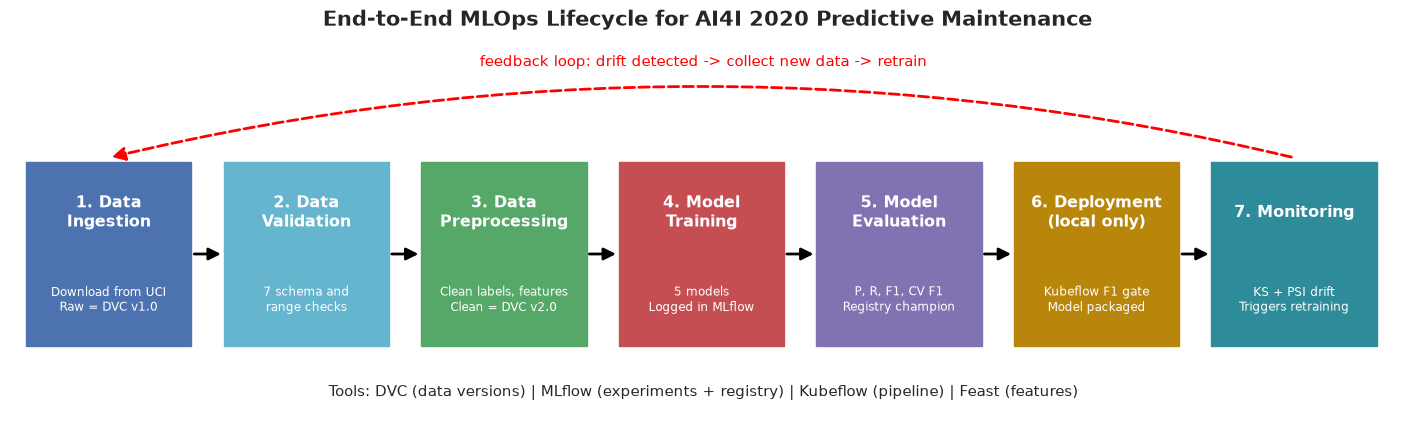

In [3]:
stages = ["1. Data\nIngestion", "2. Data\nValidation", "3. Data\nPreprocessing", "4. Model\nTraining",
          "5. Model\nEvaluation", "6. Deployment\n(local only)", "7. Monitoring"]
details = ["Download from UCI\nRaw = DVC v1.0", "7 schema and\nrange checks", "Clean labels, features\nClean = DVC v2.0",
           "5 models\nLogged in MLflow", "P, R, F1, CV F1\nRegistry champion", "Kubeflow F1 gate\nModel packaged",
           "KS + PSI drift\nTriggers retraining"]
colors = ["#4C72B0", "#64B5CD", "#55A868", "#C44E52", "#8172B2", "#B8860B", "#2E8B9A"]

fig, ax = plt.subplots(figsize=(18, 5))
for i, (stage, detail, color) in enumerate(zip(stages, details, colors)):
    x = i * 2.45
    ax.add_patch(plt.Rectangle((x, 1), 2.05, 2, color=color))
    ax.text(x + 1.025, 2.45, stage, ha="center", va="center", color="white", fontsize=11.5, fontweight="bold")
    ax.text(x + 1.025, 1.5, detail, ha="center", va="center", color="white", fontsize=8.8)
    if i < len(stages) - 1:
        ax.add_patch(FancyArrowPatch((x + 2.05, 2), (x + 2.45, 2), arrowstyle="-|>", mutation_scale=18, lw=2,
                                     color="black"))
ax.add_patch(FancyArrowPatch((15.725, 3.05), (1.025, 3.05), arrowstyle="-|>", mutation_scale=20, lw=2, color="red",
                             linestyle="--", connectionstyle="arc3,rad=0.12"))
ax.text(8.4, 4.05, "feedback loop: drift detected -> collect new data -> retrain", color="red", ha="center", fontsize=11)
ax.text(8.4, 0.45, "Tools: DVC (data versions) | MLflow (experiments + registry) | Kubeflow (pipeline) | Feast (features)",
        ha="center", fontsize=11)
ax.set_xlim(-0.2, 17.1)
ax.set_ylim(0.2, 4.4)
ax.axis("off")
ax.set_title("End-to-End MLOps Lifecycle for AI4I 2020 Predictive Maintenance", fontsize=15, fontweight="bold")
plt.savefig("reports/ml_lifecycle.png", dpi=150, bbox_inches="tight")
plt.show()

The diagram shows the lifecycle stages in order. Data validation is drawn as its own step so bad data is stopped before preprocessing. The red feedback loop sends the model back for retraining when monitoring detects drift. The figure is saved to `reports/ml_lifecycle.png`.

### 1.2 Identification of the Lifecycle Stages

| Stage | What happens for the AI4I 2020 dataset | Tool | Section |
|---|---|---|---|
| **Data ingestion** | Download the CSV (10,000 rows, 14 columns) from UCI and store the raw file as dataset version v1.0 | urllib, DVC | 2.1, 4.2 |
| **Data validation** | Seven checks (schema, missing values, duplicates, unique IDs, binary target, valid types, physical ranges); the run stops if any fails | pandas | 2.2 |
| **Data preprocessing** | Remove ID and leakage columns, remove 27 contradictory labels, one-hot encode `Type`, add power, temperature-difference and strain features, scale features | pandas, scikit-learn, DVC | 3.1, 4.3 |
| **Model training** | Train Logistic Regression, KNN, SVM, Random Forest and Gradient Boosting on a stratified 80/20 split | scikit-learn, MLflow | 3, 4.7 |
| **Model evaluation** | Compare train/test accuracy, precision, recall, F1 and confusion matrices; pick the best model by 5-fold CV F1 | MLflow | 3.4, 4.8 |
| **Deployment** | No cloud deployment in this lab. The best model is registered in the MLflow Model Registry as `champion` and loaded back for prediction; the Kubeflow pipeline passes the best model through an F1 quality gate and packages it for serving | MLflow Registry, Kubeflow | 4.9, 5 |
| **Monitoring** | Compare new sensor data with the training data using the KS test and PSI; drift triggers the retraining pipeline | SciPy, NumPy | 6 |

### 1.3 Why MLOps: DevOps vs MLOps

| Aspect | DevOps | MLOps |
|---|---|---|
| What is versioned | Code | Code, data, features, models and parameters |
| Testing | Unit and integration tests | Also data validation and model quality gates |
| Pipeline | CI/CD | CI/CD plus continuous training |
| Monitoring | Uptime, latency, errors | Also data drift and model accuracy decay |

MLOps grew out of DevOps because ML systems also depend on data, which changes over time. This notebook addresses common production challenges:
- Reproducing an old result: MLflow and DVC.
- Silent data changes: DVC.
- Manual, error-prone steps: Kubeflow.
- Training-serving skew: Feast.
- Model decay: monitoring.

## 2. Data Ingestion and Validation

### 2.1 Ingestion

In [4]:
zip_path = Path("data/ai4i2020.zip")
urllib.request.urlretrieve(DATA_URL, zip_path)
with zipfile.ZipFile(zip_path) as archive:
    archive.extract("ai4i2020.csv", "data")
zip_path.unlink()

df_raw = pd.read_csv(DATA_FILE)
RAW_MD5 = md5(DATA_FILE)
print("Shape:", df_raw.shape, "| MD5:", RAW_MD5)
df_raw.head()

Shape:

(10000, 14)

| MD5:

f0adaa9c5e25366c6df1cc2684479871

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


The raw dataset is downloaded from the UCI repository and saved to `data/ai4i2020.csv` (10,000 rows, 14 columns). Its MD5 fingerprint is stored so every experiment can be linked to this exact file.

### 2.2 Validation

In [5]:
EXPECTED_COLUMNS = ["UDI", "Product ID", "Type", "Air temperature [K]", "Process temperature [K]",
                    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]", TARGET] + FAILURE_MODES
checks = {
    "all 14 expected columns present": set(EXPECTED_COLUMNS) == set(df_raw.columns),
    "no missing values": df_raw.isna().sum().sum() == 0,
    "no duplicate rows": df_raw.duplicated().sum() == 0,
    "machine IDs are unique": df_raw["UDI"].is_unique,
    "target is binary (0/1)": set(df_raw[TARGET]) <= {0, 1},
    "product type is L, M or H": set(df_raw["Type"]) <= {"L", "M", "H"},
    "speed > 0 and torque >= 0": bool((df_raw["Rotational speed [rpm]"] > 0).all() and (df_raw["Torque [Nm]"] >= 0).all()),
}
display(pd.DataFrame({"check": checks.keys(), "result": ["PASS" if ok else "FAIL" for ok in checks.values()]}))
assert all(checks.values()), "Data validation failed - stop the pipeline"

mode_count = df_raw[FAILURE_MODES].sum(axis=1)
inconsistent = (df_raw[TARGET] == 1) != (mode_count > 0)
pd.Series({
    "Failures": df_raw[TARGET].sum(),
    "Failure rate (%)": round(df_raw[TARGET].mean() * 100, 2),
    "Labels that contradict the failure-mode columns": inconsistent.sum(),
    "Accuracy of always predicting 'no failure' (%)": round((1 - df_raw[TARGET].mean()) * 100, 2),
}, name="value", dtype=object).to_frame()

,check,result
0,all 14 expected columns present,PASS
1,no missing values,PASS
2,no duplicate rows,PASS
3,machine IDs are unique,PASS
4,target is binary (0/1),PASS
5,"product type is L, M or H",PASS
6,speed > 0 and torque >= 0,PASS


,value
Failures,339
Failure rate (%),3.39
Labels that contradict the failure-mode columns,27
Accuracy of always predicting 'no failure' (%),96.61


All seven validation checks pass. The `assert` would stop the notebook if any failed, so bad data never reaches training. The profile below the checks shows that the data is highly imbalanced: only 3.39% of the rows are failures, so a model that always predicts "no failure" already scores 96.61% accuracy. This is why precision, recall and F1 matter more than accuracy. There are also 27 rows whose label contradicts the failure-mode columns; these are cleaned in Task 3.

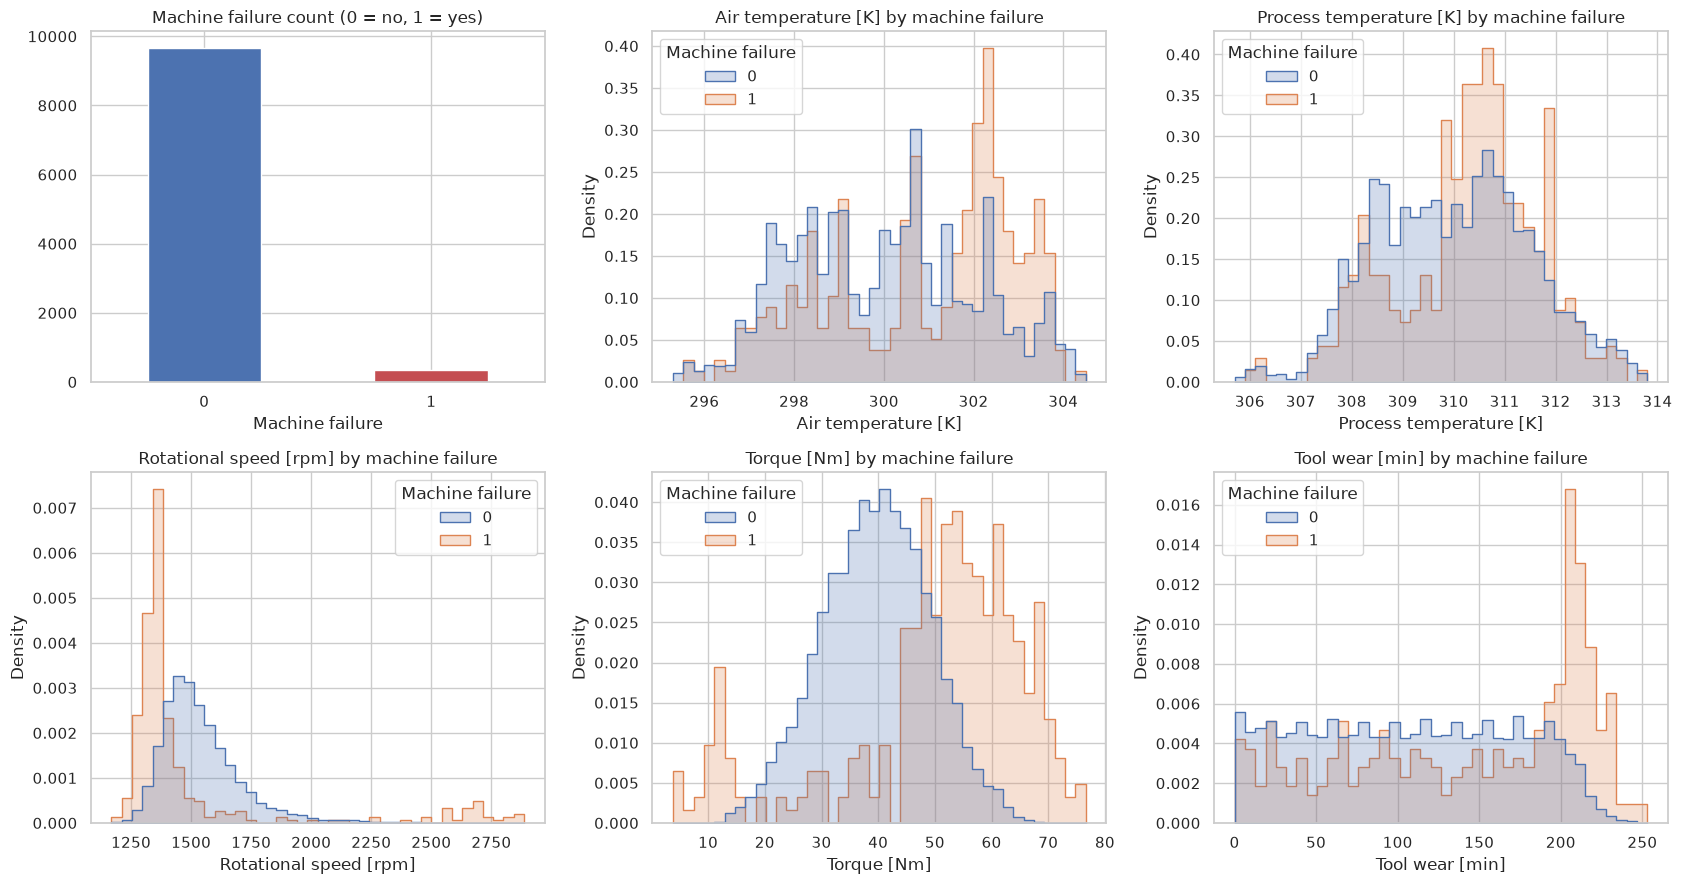

In [6]:
sensors = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
df_raw[TARGET].value_counts().plot.bar(ax=axes[0, 0], color=["#4C72B0", "#C44E52"], rot=0)
axes[0, 0].set_title("Machine failure count (0 = no, 1 = yes)")
for ax, col in zip(axes.flat[1:], sensors):
    sns.histplot(data=df_raw, x=col, hue=TARGET, stat="density", common_norm=False, bins=40, element="step", ax=ax)
    ax.set_title(f"{col} by machine failure")
plt.tight_layout()
plt.savefig("reports/eda_sensors.png", dpi=120, bbox_inches="tight")
plt.show()

The first chart shows the class imbalance. The density plots compare failed machines (orange) with healthy ones (blue): failures cluster at very high or very low torque, low rotational speed and high tool wear.

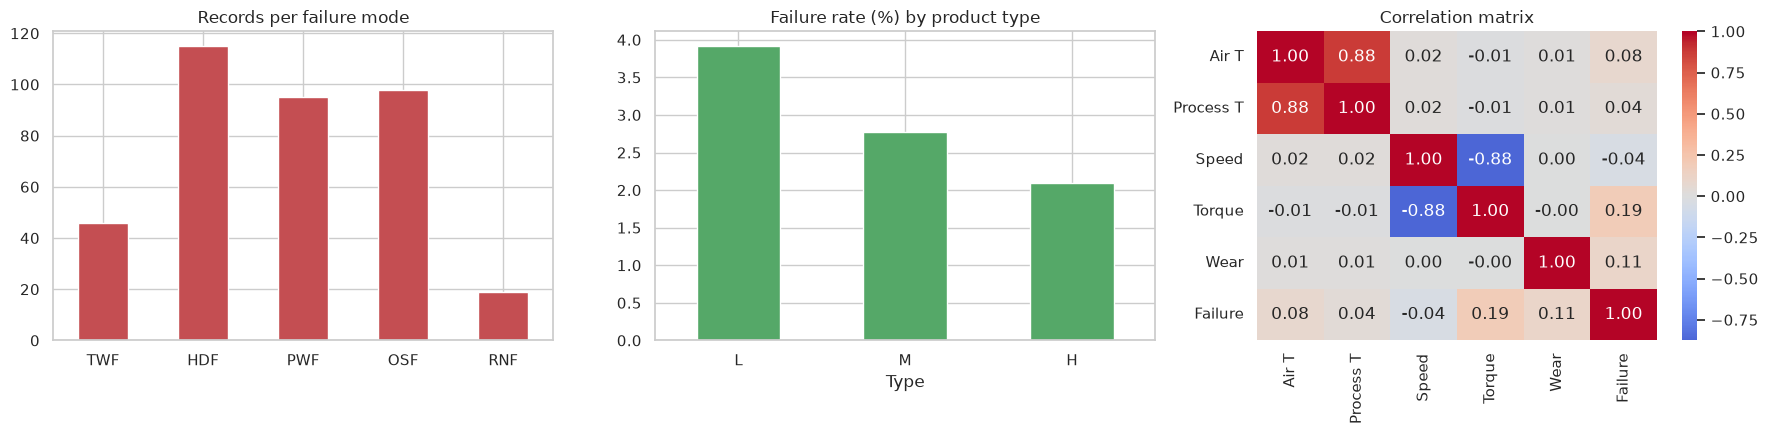

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
df_raw[FAILURE_MODES].sum().plot.bar(ax=axes[0], color="#C44E52", rot=0)
axes[0].set_title("Records per failure mode")
(df_raw.groupby("Type")[TARGET].mean() * 100).reindex(["L", "M", "H"]).plot.bar(ax=axes[1], color="#55A868", rot=0)
axes[1].set_title("Failure rate (%) by product type")
sns.heatmap(df_raw[sensors + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[2],
            xticklabels=["Air T", "Process T", "Speed", "Torque", "Wear", "Failure"],
            yticklabels=["Air T", "Process T", "Speed", "Torque", "Wear", "Failure"])
axes[2].set_title("Correlation matrix")
plt.tight_layout()
plt.show()

- **Failure modes:** heat dissipation (HDF), overstrain (OSF) and power failure (PWF) are the most common; random failures (RNF) are rare.
- **Product type:** low-quality (L) products fail most often.
- **Correlations:**
  - Torque and speed are strongly negatively correlated (-0.88), and the two temperatures are strongly positively correlated (0.88).
  - No single sensor correlates strongly with failure.
  - So failures depend on combinations of sensors, which motivates the engineered features in Task 3.

## 3. Task 2: Experiment Tracking with MLflow

### 3.1 Features for the Original Dataset (v1)

In [8]:
def make_features_v1(df):
    X = df.drop(columns=["UDI", "Product ID", TARGET] + FAILURE_MODES)
    X = pd.get_dummies(X, columns=["Type"], dtype=int)
    return X, df[TARGET]


X1, y1 = make_features_v1(df_raw)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, stratify=y1, random_state=SEED)
print("Features:", list(X1.columns))
print("Train:", X1_train.shape, "| Test:", X1_test.shape, "| Test failures:", y1_test.sum())

Features:

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M']

Train:

(8000, 8)

| Test:

(2000, 8)

| Test failures:

68

The original (v1) feature set keeps the five raw sensor readings and one-hot encodes `Type`. It drops the ID columns and the failure-mode columns, which would leak the answer. A stratified 80/20 split keeps the same failure rate in the train and test sets.

### 3.2 Models and the MLflow Tracking Function

In [9]:
MODEL_PARAMS = {
    "logistic_regression": {"C": 1.0, "max_iter": 1000, "class_weight": "balanced"},
    "knn": {"n_neighbors": 5, "weights": "distance"},
    "svm": {"C": 10.0, "kernel": "rbf", "class_weight": "balanced"},
    "random_forest": {"n_estimators": 300, "class_weight": "balanced_subsample"},
    "gradient_boosting": {"max_iter": 300, "learning_rate": 0.1, "class_weight": "balanced"},
}
MODEL_CLASSES = {"logistic_regression": LogisticRegression, "knn": KNeighborsClassifier, "svm": SVC,
                 "random_forest": RandomForestClassifier, "gradient_boosting": HistGradientBoostingClassifier}
METRICS = ["train_accuracy", "test_accuracy", "precision", "recall", "f1_score", "cv_f1"]


def build_model(name):
    params = dict(MODEL_PARAMS[name])
    if name != "knn":
        params["random_state"] = SEED
    return make_pipeline(StandardScaler(), MODEL_CLASSES[name](**params))


def train_and_log(name, X_train, X_test, y_train, y_test, data_version, data_md5):
    model = build_model(name)
    with mlflow.start_run(run_name=f"{name}_{data_version}") as active_run:
        cv_f1 = cross_val_score(model, X_train, y_train, cv=5, scoring="f1").mean()
        start = time.perf_counter()
        model.fit(X_train, y_train)
        fit_time = time.perf_counter() - start
        y_pred = model.predict(X_test)
        metrics = {
            "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
            "test_accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1_score": f1_score(y_test, y_pred),
            "cv_f1": cv_f1,
        }
        mlflow.log_params({**MODEL_PARAMS[name], "model": name, "data_version": data_version,
                           "data_md5": data_md5, "seed": SEED, "test_size": 0.2})
        mlflow.log_metrics({**metrics, "overfit_gap": metrics["train_accuracy"] - metrics["test_accuracy"],
                            "fit_time_sec": fit_time})
        mlflow.set_tags({"run_group": RUN_GROUP, "data_version": data_version, "git_commit": GIT_COMMIT})
        mlflow.log_input(mlflow.data.from_pandas(X_train.assign(target=y_train.values), name=f"ai4i_{data_version}",
                                                 targets="target"), context="training")
        mlflow.log_text(classification_report(y_test, y_pred, target_names=["No failure", "Failure"], digits=4),
                        "classification_report.txt")
        fig, ax = plt.subplots(figsize=(4, 4))
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
        mlflow.log_figure(fig, "confusion_matrix.png")
        plt.close(fig)
        model_info = mlflow.sklearn.log_model(model, name="model", input_example=X_train.head(3),
                                              serialization_format="cloudpickle")
    return {"model": name, "data_version": data_version, **metrics, "fitted_model": model, "y_pred": y_pred,
            "run_id": active_run.info.run_id, "model_uri": model_info.model_uri}


def load_runs():
    runs = mlflow.search_runs(experiment_names=[EXPERIMENT], filter_string=f"tags.run_group = '{RUN_GROUP}'")
    columns = ["params.model", "tags.data_version"] + [f"metrics.{m}" for m in METRICS + ["overfit_gap", "fit_time_sec"]]
    table = runs[columns]
    table.columns = ["model", "data_version"] + METRICS + ["overfit_gap", "fit_time_sec"]
    return table.sort_values("f1_score", ascending=False).reset_index(drop=True)

The five models are defined by name with their hyperparameters, and each is wrapped in a scaler-plus-classifier pipeline. For each model, `train_and_log` opens one MLflow run and logs:
- **Parameters:** hyperparameters, data version and data MD5.
- **Metrics:** training and testing accuracy, precision, recall, F1, 5-fold CV F1, overfitting gap and fit time.
- **Training dataset:** recorded as a run input.
- **Artifacts:** classification report and confusion-matrix image.
- **Model:** the trained model with its input signature.

`load_runs` reads the runs back from MLflow.

### 3.3 Train Five Models on the Original Dataset (v1)

In [10]:
results = [train_and_log(name, X1_train, X1_test, y1_train, y1_test, "v1", RAW_MD5) for name in MODEL_PARAMS]
pd.DataFrame(results)[["model"] + METRICS].round(4)

,model,train_accuracy,test_accuracy,precision,recall,f1_score,cv_f1
0,logistic_regression,0.8218,0.8250,0.1421,0.8235,0.2424,0.2349
1,knn,1.0000,0.9755,0.8519,0.3382,0.4842,0.4365
2,svm,0.9419,0.9260,0.2938,0.8382,0.4351,0.4735
3,random_forest,1.0000,0.9795,0.9355,0.4265,0.5859,0.5533
4,gradient_boosting,1.0000,0.9855,0.8197,0.7353,0.7752,0.7459


Each model becomes one MLflow run. Test accuracy ranges from 0.83 to 0.99, but F1 on the failure class ranges far more widely, from 0.24 (Logistic Regression) to 0.78 (Gradient Boosting), which shows how hard the rare class is.

### 3.4 Compare the Experiments using MLflow

In [11]:
v1_runs = load_runs()
v1_runs.round(4)

,model,data_version,train_accuracy,test_accuracy,precision,recall,f1_score,cv_f1,overfit_gap,fit_time_sec
0,gradient_boosting,v1,1.0000,0.9855,0.8197,0.7353,0.7752,0.7459,0.0145,0.4298
1,random_forest,v1,1.0000,0.9795,0.9355,0.4265,0.5859,0.5533,0.0205,1.0852
2,knn,v1,1.0000,0.9755,0.8519,0.3382,0.4842,0.4365,0.0245,0.0054
3,svm,v1,0.9419,0.9260,0.2938,0.8382,0.4351,0.4735,0.0159,0.1983
4,logistic_regression,v1,0.8218,0.8250,0.1421,0.8235,0.2424,0.2349,-0.0032,0.0088


This comparison table is read back from the MLflow tracking store with `mlflow.search_runs`, sorted by failure-class F1. It is the same data the MLflow UI shows in its **Compare** view. `overfit_gap` is training minus testing accuracy, and `fit_time_sec` is the training time.

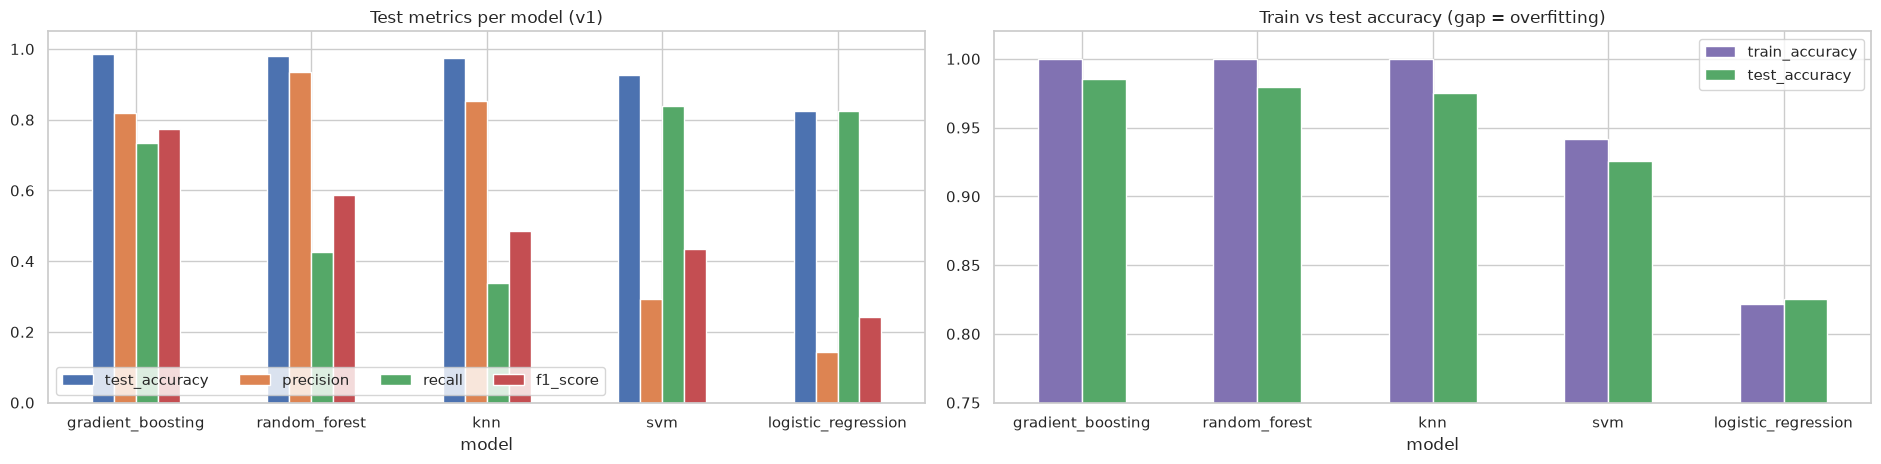

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(19, 4.8))
v1_runs.set_index("model")[["test_accuracy", "precision", "recall", "f1_score"]].plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Test metrics per model (v1)")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="lower left", ncol=4)
v1_runs.set_index("model")[["train_accuracy", "test_accuracy"]].plot.bar(ax=axes[1], rot=0, color=["#8172B2", "#55A868"])
axes[1].set_title("Train vs test accuracy (gap = overfitting)")
axes[1].set_ylim(0.75, 1.02)
plt.tight_layout()
plt.savefig("reports/mlflow_comparison_v1.png", dpi=120, bbox_inches="tight")
plt.show()

The left chart shows the accuracy paradox: accuracy stays high while precision, recall and F1 on failures vary widely, so F1 is the fair metric for comparing models. The right chart compares training and test accuracy. KNN, Random Forest and Gradient Boosting fit the training data perfectly (1.0), but their test accuracy stays above 0.97, so the overfitting gap is small (at most 0.025).

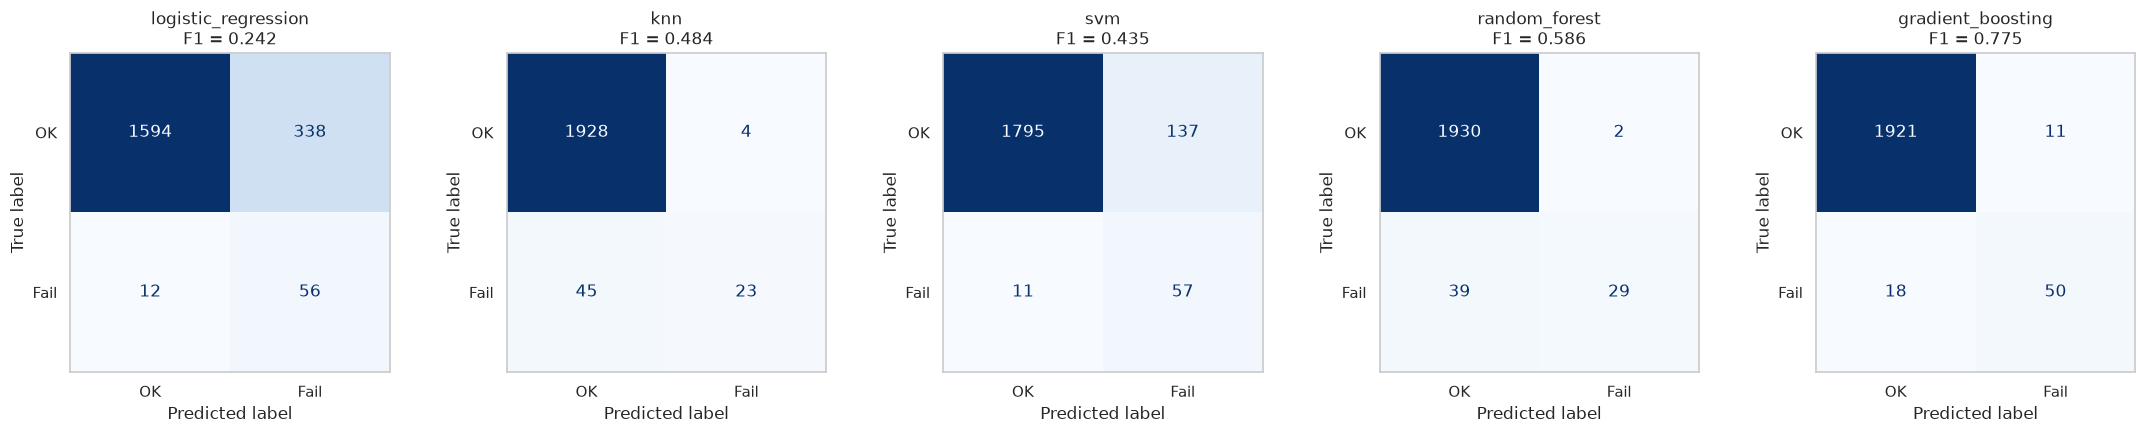

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, r in zip(axes, results):
    ConfusionMatrixDisplay.from_predictions(y1_test, r["y_pred"], ax=ax, colorbar=False, display_labels=["OK", "Fail"],
                                            cmap="Blues")
    ax.set_title(f"{r['model']}\nF1 = {r['f1_score']:.3f}")
    ax.grid(False)
plt.tight_layout()
plt.show()

The confusion matrices show different trade-offs:
- The class-weighted Logistic Regression and SVM catch most failures (recall 0.82–0.84) but raise many false alarms.
- KNN and Random Forest raise very few false alarms but miss more than half of the failures.
- Gradient Boosting has the best balance on v1 (precision 0.82, recall 0.74).

**Viewing the runs in the MLflow UI:**
1. In a terminal in the project folder, run `mlflow ui --backend-store-uri sqlite:///mlflow.db`.
2. Open `http://127.0.0.1:5000` and select the experiment `ai4i-predictive-maintenance`.
3. Tick the runs and click **Compare**.

The UI shows parameter differences, metric charts, each run's dataset, artifacts and saved model, and the registered champion under **Models**.

## 4. Task 3: Dataset Versioning with DVC

### 4.1 Initialize a DVC Repository

In [14]:
run("dvc init")
run("dvc remote add -d localstore dvc_storage")
run("git add .dvc .dvcignore")
run('git commit -m "chore(dvc): initialize DVC with a local remote"')

$ dvc init

Initialized DVC repository.

You can now commit the changes to git.

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/treeverse/dvc>

$ dvc remote add -d localstore dvc_storage

Setting 'localstore' as a default remote.

$ git add .dvc .dvcignore

$ git commit -m "chore(dvc): initialize DVC with a local remote"

[main 7c3a36c] chore(dvc): initialize DVC with a local remote
 3 files changed, 10 insertions(+)
 create mode 100644 .dvc/.gitignore
 create mode 100644 .dvc/config
 create mode 100644 .dvcignore

`dvc init` creates the `.dvc/` folder inside the existing Git repository. A local folder `dvc_storage/` is set as the default remote, playing the role S3 or Google Cloud Storage would play in a team. The setup is committed to Git.

### 4.2 Add the Original Dataset to DVC (Version 1)

In [15]:
run("dvc add data/ai4i2020.csv")
run("git add data/ai4i2020.csv.dvc data/.gitignore")
run('git commit -m "feat(data): track original AI4I 2020 dataset (v1.0)"')
run('git tag -a data-v1.0 -m "Original dataset"')
run("dvc push")
print(Path("data/ai4i2020.csv.dvc").read_text())
print("MD5 in DVC matches MD5 logged in MLflow v1 runs:", RAW_MD5 in Path("data/ai4i2020.csv.dvc").read_text())

$ dvc add data/ai4i2020.csv

To track the changes with git, run:

	git add data/ai4i2020.csv.dvc data/.gitignore

To enable auto staging, run:

	dvc config core.autostage true

$ git add data/ai4i2020.csv.dvc data/.gitignore

$ git commit -m "feat(data): track original AI4I 2020 dataset (v1.0)"

[main fa33570] feat(data): track original AI4I 2020 dataset (v1.0)
 2 files changed, 6 insertions(+)
 create mode 100644 data/.gitignore
 create mode 100644 data/ai4i2020.csv.dvc

...

$ dvc push

1 file pushed

outs:
- md5: f0adaa9c5e25366c6df1cc2684479871
  size: 522048
  hash: md5
  path: ai4i2020.csv


MD5 in DVC matches MD5 logged in MLflow v1 runs:

True

`dvc add` stores the CSV in the DVC cache, and Git tracks only the small `.dvc` pointer file holding the file's MD5. The pointer is committed, tagged `data-v1.0` and pushed to the DVC remote. Its MD5 matches the one logged in the MLflow v1 runs, which links the experiments to this exact data.

### 4.3 Create the Modified Dataset with Added Preprocessing (Version 2)

In [16]:
RENAME = {"UDI": "machine_id", "Product ID": "product_id", "Type": "type", "Air temperature [K]": "air_temp_k",
          "Process temperature [K]": "process_temp_k", "Rotational speed [rpm]": "rotational_speed_rpm",
          "Torque [Nm]": "torque_nm", "Tool wear [min]": "tool_wear_min", "Machine failure": "machine_failure"}


def preprocess(df):
    consistent = (df[TARGET] == 1) == (df[FAILURE_MODES].sum(axis=1) > 0)
    out = df[consistent].rename(columns=RENAME).drop(columns=["product_id"] + FAILURE_MODES)
    out["temp_diff_k"] = (out["process_temp_k"] - out["air_temp_k"]).round(2)
    out["power_w"] = (out["torque_nm"] * out["rotational_speed_rpm"] * 2 * np.pi / 60).round(2)
    out["strain_min_nm"] = (out["tool_wear_min"] * out["torque_nm"]).round(2)
    out = pd.get_dummies(out, columns=["type"], dtype=int)
    out["machine_failure"] = out.pop("machine_failure")
    return out.reset_index(drop=True)


df_v2 = preprocess(df_raw)
df_v2.to_csv(DATA_FILE, index=False)
V2_MD5 = md5(DATA_FILE)
print("v1 shape:", df_raw.shape, "-> v2 shape:", df_v2.shape)
df_v2.head()

v1 shape:

(10000, 14)

-> v2 shape:

(9973, 13)

,machine_id,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,temp_diff_k,power_w,strain_min_nm,type_H,type_L,type_M,machine_failure
0,1,298.1,308.6,1551,42.8,0,10.5,6951.59,0.0,0,0,1,0
1,2,298.2,308.7,1408,46.3,3,10.5,6826.72,138.9,0,1,0,0
2,3,298.1,308.5,1498,49.4,5,10.4,7749.39,247.0,0,1,0,0
3,4,298.2,308.6,1433,39.5,7,10.4,5927.50,276.5,0,1,0,0
4,5,298.2,308.7,1408,40.0,9,10.5,5897.82,360.0,0,1,0,0


The preprocessing step:
- removes the 27 contradictory labels
- renames the columns to clean names
- drops the product ID and the five leakage columns
- one-hot encodes the product type
- adds three physics-based features: temperature difference, power in watts, and wear × torque strain

The result overwrites the same file path, which becomes version 2.

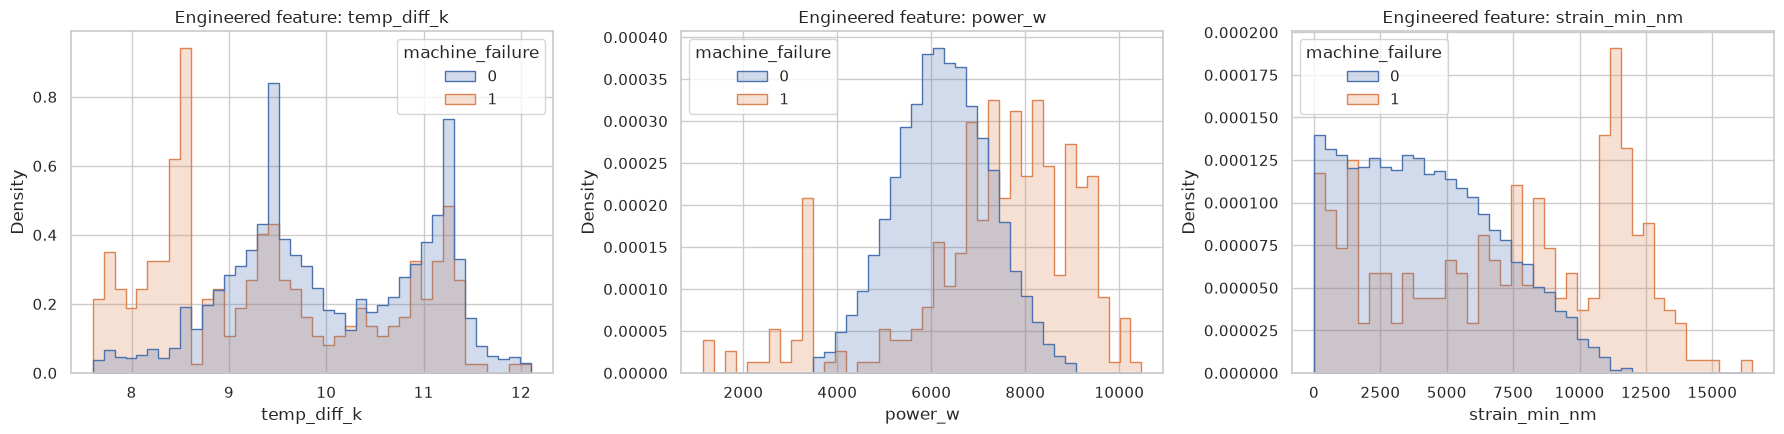

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, col in zip(axes, ["temp_diff_k", "power_w", "strain_min_nm"]):
    sns.histplot(data=df_v2, x=col, hue="machine_failure", stat="density", common_norm=False, bins=40,
                 element="step", ax=ax)
    ax.set_title(f"Engineered feature: {col}")
plt.tight_layout()
plt.savefig("reports/engineered_features.png", dpi=120, bbox_inches="tight")
plt.show()

The new features separate failures much better than the raw sensors did. Failures concentrate at low temperature difference, at very low or very high power, and at high strain. These match the physical failure rules: heat dissipation, power and overstrain.

### 4.4 Add the Modified Dataset to DVC (Version 2)

In [18]:
run("dvc status")
run("dvc add data/ai4i2020.csv")
run("git add data/ai4i2020.csv.dvc")
run('git commit -m "feat(data): track preprocessed AI4I 2020 dataset (v2.0)"')
run('git tag -a data-v2.0 -m "Preprocessed dataset with engineered features"')
run("dvc push")
run("git log --oneline --decorate")

$ dvc status

data/ai4i2020.csv.dvc:
	changed outs:
		modified:           data/ai4i2020.csv

$ dvc add data/ai4i2020.csv

To track the changes with git, run:

	git add data/ai4i2020.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true

$ git add data/ai4i2020.csv.dvc

...

$ git tag -a data-v2.0 -m "Preprocessed dataset with engineered features"

$ dvc push

1 file pushed

$ git log --oneline --decorate

b737eeb (HEAD -> main, tag: data-v2.0) feat(data): track preprocessed AI4I 2020 dataset (v2.0)
fa33570 (tag: data-v1.0) feat(data): track original AI4I 2020 dataset (v1.0)
7c3a36c chore(dvc): initialize DVC with a local remote
a69673f chore: project scaffold with pinned requirements, Dockerfile and gitignore

`dvc status` detects that the tracked file changed. `dvc add` stores the new version, and the updated pointer is committed and tagged `data-v2.0`. The Git log now shows both dataset versions as separate tagged commits.

### 4.5 Compare Both Versions

In [19]:
run("dvc diff data-v1.0 data-v2.0")
v1 = pd.read_csv(StringIO(dvc.api.read("data/ai4i2020.csv", rev="data-v1.0")))
v2 = pd.read_csv(StringIO(dvc.api.read("data/ai4i2020.csv", rev="data-v2.0")))
pd.DataFrame({
    "v1.0 original": [v1.shape[0], v1.shape[1], v1[TARGET].sum(), round(v1[TARGET].mean() * 100, 2), 27, RAW_MD5],
    "v2.0 preprocessed": [v2.shape[0], v2.shape[1], v2["machine_failure"].sum(),
                          round(v2["machine_failure"].mean() * 100, 2), 0, V2_MD5],
}, index=["Rows", "Columns", "Failures", "Failure rate (%)", "Contradictory labels", "MD5"])

$ dvc diff data-v1.0 data-v2.0

Modified:
    data/ai4i2020.csv

files summary: 1 modified

,v1.0 original,v2.0 preprocessed
Rows,10000,9973
Columns,14,13
Failures,339,330
Failure rate (%),3.39,3.31
Contradictory labels,27,0
MD5,f0adaa9c5e25366c6df1cc2684479871,43cc5023d0592ac6f4f02be1cca603c5


`dvc diff` confirms that the data file changed between the two tags. Both versions are loaded straight from Git history with `dvc.api.read`. Version 2 has 27 fewer rows and no contradictory labels. It has 13 columns instead of 14, because seven columns were removed and six were added (three engineered features and three type columns).

### 4.6 Switch Between Dataset Versions

In [20]:
run("git checkout data-v1.0 -- data/ai4i2020.csv.dvc")
run("dvc checkout")
print("Workspace after switching to v1.0:", pd.read_csv(DATA_FILE).shape)
run("git checkout HEAD -- data/ai4i2020.csv.dvc")
run("dvc checkout")
print("Workspace after switching back to v2.0:", pd.read_csv(DATA_FILE).shape)

$ git checkout data-v1.0 -- data/ai4i2020.csv.dvc

$ dvc checkout

M       data/ai4i2020.csv

Workspace after switching to v1.0:

(10000, 14)

$ git checkout HEAD -- data/ai4i2020.csv.dvc

$ dvc checkout

M       data/ai4i2020.csv

Workspace after switching back to v2.0:

(9973, 13)

This shows switching between data versions: checking out the v1.0 pointer and running `dvc checkout` restores the original 10,000 × 14 file, and switching back restores the 9,973 × 13 file. Any past experiment can be reproduced this way.

### 4.7 Retrain on Version 2 and Compare with Version 1

In [21]:
X2 = df_v2.drop(columns=["machine_id", "machine_failure"])
y2 = df_v2["machine_failure"]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=SEED)
results += [train_and_log(name, X2_train, X2_test, y2_train, y2_test, "v2", V2_MD5) for name in MODEL_PARAMS]
all_runs = load_runs()
all_runs.pivot(index="model", columns="data_version", values=["precision", "recall", "f1_score"]).round(4)

precision          recall         f1_score        
data_version               v1      v2      v1      v2       v1      v2
model                                                                 
gradient_boosting      0.8197  0.8889  0.7353  0.8485   0.7752  0.8682
knn                    0.8519  0.7647  0.3382  0.3939   0.4842  0.5200
logistic_regression    0.1421  0.1690  0.8235  0.9091   0.2424  0.2850
random_forest          0.9355  0.9344  0.4265  0.8636   0.5859  0.8976
svm                    0.2938  0.4118  0.8382  0.8485   0.4351  0.5545

The same five models, with the same hyperparameters, are retrained on version 2 and logged to MLflow with `data_version = v2`. Only the data changed, so any difference in the metrics comes from the preprocessing.

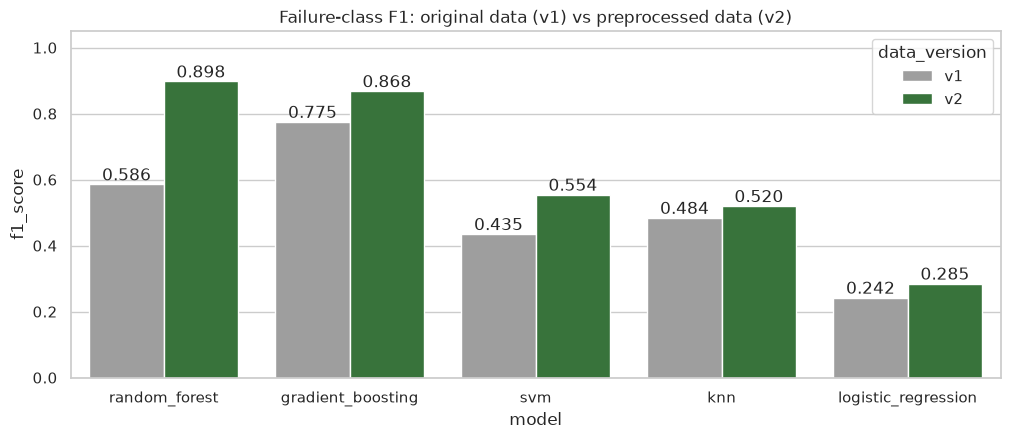

In [22]:
plt.figure(figsize=(12, 4.5))
ax = sns.barplot(data=all_runs, x="model", y="f1_score", hue="data_version", palette=["#9E9E9E", "#2E7D32"],
                 hue_order=["v1", "v2"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
plt.ylim(0, 1.05)
plt.title("Failure-class F1: original data (v1) vs preprocessed data (v2)")
plt.savefig("reports/f1_v1_vs_v2.png", dpi=120, bbox_inches="tight")
plt.show()

F1 improves for every model on version 2:
- **Random Forest** gains the most (0.586 to 0.898).
- **SVM** follows (0.435 to 0.555).
- **Gradient Boosting** comes next (0.775 to 0.868).

The engineered features encode the physical failure rules, and the cleaned labels remove contradictory training signals. This is the clearest evidence of why the data version must be tracked with every result.

### 4.8 Best Model and Feature Importance

Best model by CV F1 on v2: random_forest (CV F1 = 0.8780, test F1 = 0.8976)

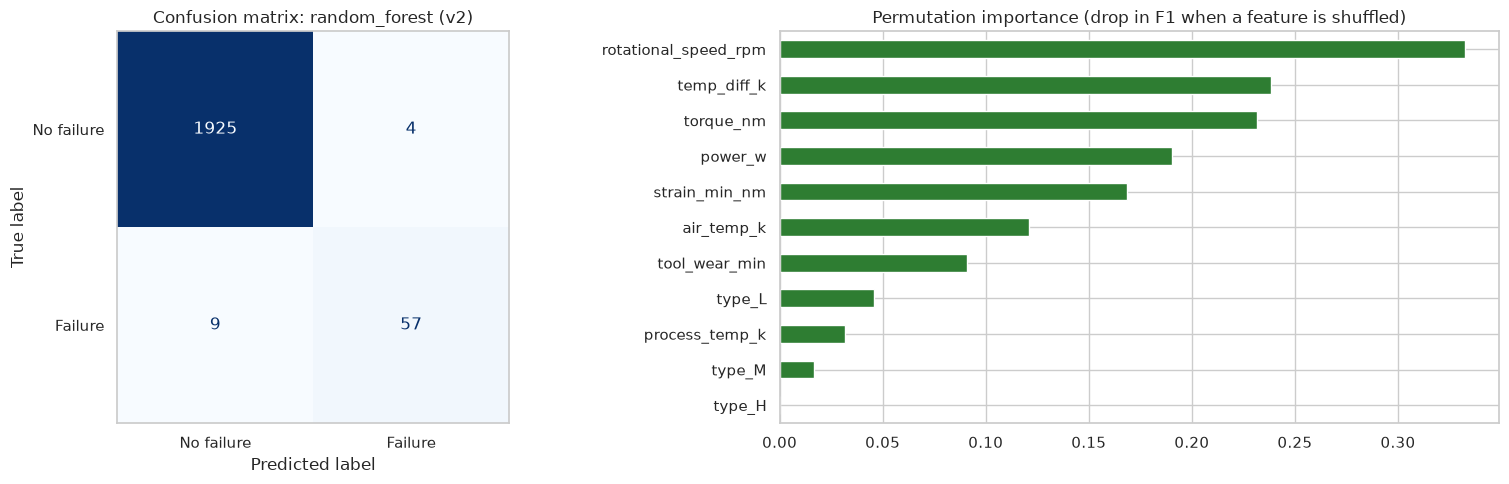

In [23]:
best = max([r for r in results if r["data_version"] == "v2"], key=lambda r: r["cv_f1"])
best_model = best["fitted_model"]
print(f"Best model by CV F1 on v2: {best['model']} (CV F1 = {best['cv_f1']:.4f}, test F1 = {best['f1_score']:.4f})")

importance = permutation_importance(best_model, X2_test, y2_test, scoring="f1", n_repeats=5, random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ConfusionMatrixDisplay.from_predictions(y2_test, best["y_pred"], ax=axes[0], colorbar=False,
                                        display_labels=["No failure", "Failure"], cmap="Blues")
axes[0].set_title(f"Confusion matrix: {best['model']} (v2)")
axes[0].grid(False)
pd.Series(importance.importances_mean, index=X2.columns).sort_values().plot.barh(ax=axes[1], color="#2E7D32")
axes[1].set_title("Permutation importance (drop in F1 when a feature is shuffled)")
plt.tight_layout()
plt.savefig("reports/best_model.png", dpi=120, bbox_inches="tight")
plt.show()

The best model on the final v2 dataset is chosen by 5-fold cross-validated F1 on the training data, so the test set plays no part in the choice: Random Forest, with CV F1 0.878. Its confusion matrix shows 57 of 66 failures caught with only 4 false alarms. Permutation importance measures how much F1 drops when one feature is shuffled. The engineered temperature difference ranks second, and all three engineered features (temperature difference, power and strain) rank above the raw air temperature, tool wear and process temperature.

### 4.9 Register the Champion in the MLflow Model Registry

In [24]:
with redirect_stderr(StringIO()):
    version = mlflow.register_model(best["model_uri"], REGISTERED_MODEL)
client = mlflow.MlflowClient()
client.set_registered_model_alias(REGISTERED_MODEL, "champion", version.version)
client.set_model_version_tag(REGISTERED_MODEL, version.version, "data_version", "v2")
champion = mlflow.pyfunc.load_model(f"models:/{REGISTERED_MODEL}@champion")
champion_pred = champion.predict(X2_test)
print(f"Registered {REGISTERED_MODEL} version {version.version} with alias 'champion' ({best['model']}, data v2)")
print("Registry model predictions identical to the trained model:", bool((champion_pred == best["y_pred"]).all()))
print(f"Champion test F1 (loaded from the registry): {f1_score(y2_test, champion_pred):.4f}")

Registered ai4i-failure-classifier version 1 with alias 'champion' (random_forest, data v2)

Registry model predictions identical to the trained model:

True

Champion test F1 (loaded from the registry): 0.8976

The best run's saved model is registered in the MLflow Model Registry and given the `champion` alias. It is then loaded back by that alias, exactly as a serving system would load it, and its predictions match the trained model.

**Deployment readiness (not executed, because cloud deployment is out of scope for this lab):** `mlflow models serve -m "models:/ai4i-failure-classifier@champion" -p 5001` would expose this champion as a local REST endpoint. The same registered model could be uploaded to the Vertex AI or SageMaker model registry.

### 4.10 Failure Cases of the Best Model

In [25]:
cases = X2_test.assign(actual=y2_test.values, predicted=best["y_pred"])
errors = cases[cases["actual"] != cases["predicted"]]
print("Missed failures:", (errors["actual"] == 1).sum(), "| False alarms:", (errors["actual"] == 0).sum())
errors[["rotational_speed_rpm", "torque_nm", "tool_wear_min", "temp_diff_k", "power_w", "strain_min_nm",
        "actual", "predicted"]]

Missed failures:

9

| False alarms:

4

,rotational_speed_rpm,torque_nm,tool_wear_min,temp_diff_k,power_w,strain_min_nm,actual,predicted
4221,1340,47.8,54,8.6,6707.51,2581.2,0,1
3785,1356,48.3,36,8.6,6858.60,1738.8,0,1
3228,1342,62.4,113,8.6,8769.32,7051.2,1,0
4805,1521,35.9,215,8.6,5718.11,7718.5,1,0
1992,1416,38.2,198,9.6,5664.42,7563.6,1,0
3520,1567,39.0,214,9.0,6399.74,8346.0,1,0
2665,1399,41.9,221,9.6,6138.47,9259.9,1,0
2239,1542,37.5,203,9.1,6055.42,7612.5,1,0
3800,1350,56.6,76,8.6,8001.64,4301.6,0,1
7486,1524,38.9,214,11.3,6208.16,8324.6,1,0


These are the 13 test rows the best model got wrong, and most sit on the edge of a physical failure rule:
- **False alarms (4):** three are low-speed readings (below 1,380 rpm) with a temperature difference of exactly 8.6 K, right on the heat-dissipation boundary. The fourth has a very high strain of 11,492 min·Nm, close to the overstrain limit.
- **Missed failures (9):** eight have tool wear between 198 and 234 minutes, the window in which tool-wear failures happen at a random moment, so they cannot be predicted exactly. The remaining one is a low-speed reading with a temperature difference of exactly 8.6 K.

### 4.11 Benefits of Data Versioning

- **Reproducibility:** each MLflow run stores the MD5 of its data, and `git checkout <tag>` followed by `dvc checkout` brings back that exact dataset.
- **Traceability:** the Git history records who changed the data, when and why, and the registered champion carries a `data_version` tag.
- **Safe experimentation:** new preprocessing can be tried without losing the original, and a rollback takes seconds.
- **Fair comparison:** with code and hyperparameters fixed, the v1-vs-v2 F1 gain can be attributed to the data change alone.
- **Storage efficiency:** Git holds only tiny pointer files; large data sits in the DVC cache and remote.
- **Collaboration:** teammates run `dvc pull` to get exactly the data version that matches the code.

## 5. Task 4: Workflow Automation with Kubeflow Pipelines

### 5.1 Pipeline Design

`Data Collection -> Data Validation -> Training x3 (in parallel) -> Evaluation -> F1 quality gate -> Deployment`

| Step | Kubeflow component | Input | Output |
|---|---|---|---|
| 1. Data Collection | `data_collection` | Source URL | Raw dataset |
| 2. Data Validation | `data_validation` | Raw dataset | Validation report (metrics) and the clean, feature-engineered dataset |
| 3. Training (3 parallel branches) | `train_model` | Clean dataset, model type | Trained model (Logistic Regression, Random Forest, Gradient Boosting) |
| 4. Evaluation | `evaluate_models` | Clean dataset and 3 models | Metrics per model, plus the best model, its name and its F1 |
| 5. Deployment | `deployment` | Best model and its F1 | Packaged model with manifest; runs only if F1 ≥ threshold |

**Kubeflow concepts used:**
- **Components:** each step is a containerised Python function.
- **Typed artifacts:** `Dataset`, `Model` and `Metrics` are passed between steps.
- **Named outputs:** evaluation returns the best model's name and F1.
- **Pipeline parameters:** values such as the data URL and threshold can change per run.
- **Parallel branches:** the three training steps do not depend on each other.
- **Conditional step:** `dsl.If` implements the quality gate.
- **Retries and resource limits:** per-step settings for reliability and capacity.
- **Compiler:** produces a portable YAML spec.

> **How this section runs**
> - **Compiled:** the real KFP v2 compiler produces `pipelines/ai4i_pipeline.yaml`, including the `dsl.If` quality gate. This file can be uploaded unchanged to a Kubeflow Pipelines cluster or Vertex AI Pipelines.
> - **Executed for real:** the pipeline runs with KFP's local runner (`SubprocessRunner`). Each component runs as its own process, artifacts are written to disk, and steps run in DAG order. The local runner needs Linux or macOS, so this notebook was executed in a Linux Docker container.
> - **Not exercised locally:** Kubernetes pods, resource limits, caching and retries. The local runner also does not execute `dsl.If` branches, so the locally executed variant applies the same F1 threshold inside the deployment step instead.

### 5.2 Pipeline Components (KFP SDK v2)

In [26]:
from typing import NamedTuple
from kfp import dsl, compiler, local
from kfp.dsl import Input, Output, Dataset, Model, Metrics

PACKAGES = ["pandas==2.3.3", "scikit-learn==1.5.2", "joblib"]
MODEL_TYPES = ["logistic_regression", "random_forest", "gradient_boosting"]


@dsl.component(base_image="python:3.11-slim", packages_to_install=PACKAGES)
def data_collection(source_url: str, raw_data: Output[Dataset]):
    import io
    import urllib.request
    import zipfile
    import pandas as pd
    archive = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(source_url).read()))
    df = pd.read_csv(archive.open("ai4i2020.csv"))
    df.to_csv(raw_data.path, index=False)
    raw_data.metadata.update({"rows": len(df), "columns": df.shape[1]})
    print(f"Collected {len(df)} rows and {df.shape[1]} columns")


@dsl.component(base_image="python:3.11-slim", packages_to_install=PACKAGES)
def data_validation(raw_data: Input[Dataset], clean_data: Output[Dataset], report: Output[Metrics]):
    import numpy as np
    import pandas as pd
    df = pd.read_csv(raw_data.path)
    modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]
    checks = {
        "enough_rows": len(df) >= 5000,
        "no_missing_values": df.isna().sum().sum() == 0,
        "unique_ids": df["UDI"].is_unique,
        "binary_target": set(df["Machine failure"]) <= {0, 1},
        "valid_product_types": set(df["Type"]) <= {"L", "M", "H"},
        "positive_speed": (df["Rotational speed [rpm]"] > 0).all(),
    }
    for name, passed in checks.items():
        report.log_metric(name, float(passed))
    if not all(checks.values()):
        raise ValueError(f"Data validation failed: {checks}")
    consistent = (df["Machine failure"] == 1) == (df[modes].sum(axis=1) > 0)
    df = df[consistent].drop(columns=["UDI", "Product ID"] + modes)
    df["temp_diff_k"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    df["power_w"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * 2 * np.pi / 60
    df["strain_min_nm"] = df["Tool wear [min]"] * df["Torque [Nm]"]
    df = pd.get_dummies(df, columns=["Type"], dtype=int)
    df.to_csv(clean_data.path, index=False)
    clean_data.metadata.update({"rows": len(df), "contradictory_rows_removed": int((~consistent).sum())})
    print(f"All {len(checks)} checks passed, removed {(~consistent).sum()} contradictory rows")


@dsl.component(base_image="python:3.11-slim", packages_to_install=PACKAGES)
def train_model(clean_data: Input[Dataset], model_type: str, seed: int, model: Output[Model]):
    import joblib
    import pandas as pd
    from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    df = pd.read_csv(clean_data.path)
    X, y = df.drop(columns=["Machine failure"]), df["Machine failure"]
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    estimators = {
        "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed),
        "random_forest": RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", random_state=seed),
        "gradient_boosting": HistGradientBoostingClassifier(max_iter=300, class_weight="balanced", random_state=seed),
    }
    pipeline = make_pipeline(StandardScaler(), estimators[model_type]).fit(X_train, y_train)
    joblib.dump(pipeline, model.path)
    model.metadata["model_type"] = model_type
    print(f"Trained {model_type} on {len(X_train)} rows")


@dsl.component(base_image="python:3.11-slim", packages_to_install=PACKAGES)
def evaluate_models(clean_data: Input[Dataset], lr_model: Input[Model], rf_model: Input[Model],
                    gb_model: Input[Model], seed: int, best_model: Output[Model],
                    metrics: Output[Metrics]) -> NamedTuple("EvalOutputs", [("best_model_type", str), ("best_f1", float)]):
    import shutil
    from collections import namedtuple
    import joblib
    import pandas as pd
    from sklearn.metrics import f1_score, precision_score, recall_score
    from sklearn.model_selection import train_test_split
    df = pd.read_csv(clean_data.path)
    X, y = df.drop(columns=["Machine failure"]), df["Machine failure"]
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    candidates = {"logistic_regression": lr_model, "random_forest": rf_model, "gradient_boosting": gb_model}
    f1_scores = {}
    for name, artifact in candidates.items():
        y_pred = joblib.load(artifact.path).predict(X_test)
        f1_scores[name] = float(f1_score(y_test, y_pred))
        metrics.log_metric(f"{name}_precision", round(float(precision_score(y_test, y_pred)), 4))
        metrics.log_metric(f"{name}_recall", round(float(recall_score(y_test, y_pred)), 4))
        metrics.log_metric(f"{name}_f1", round(f1_scores[name], 4))
    best = max(f1_scores, key=f1_scores.get)
    shutil.copy(candidates[best].path, best_model.path)
    best_model.metadata.update({"model_type": best, "f1_score": round(f1_scores[best], 4)})
    print(f"Best model: {best} with F1 = {f1_scores[best]:.4f}")
    return namedtuple("EvalOutputs", ["best_model_type", "best_f1"])(best, f1_scores[best])


@dsl.component(base_image="python:3.11-slim", packages_to_install=PACKAGES)
def deployment(best_model: Input[Model], best_model_type: str, f1: float, f1_threshold: float,
               packaged_model: Output[Model]) -> str:
    import shutil
    if f1 < f1_threshold:
        print(f"Quality gate failed: F1 {f1:.4f} < {f1_threshold}")
        return "REJECTED"
    shutil.copy(best_model.path, packaged_model.path)
    packaged_model.metadata.update({"model_name": "ai4i-failure-classifier", "model_type": best_model_type,
                                    "f1_score": round(f1, 4), "status": "READY_FOR_SERVING"})
    print(f"Quality gate passed (F1 {f1:.4f} >= {f1_threshold}): {best_model_type} packaged for serving")
    return "READY_FOR_SERVING"


print("Components defined:", [c.name for c in [data_collection, data_validation, train_model, evaluate_models, deployment]])

Components defined:

['data-collection', 'data-validation', 'train-model', 'evaluate-models', 'deployment']

The pipeline has five components:
- **Data collection** downloads the raw data.
- **Data validation** runs six checks, stops the pipeline if any fails, and prepares the model-ready features.
- **Training** is one reusable component, called three times with different model types.
- **Evaluation** scores the three models and passes on the best one, with its name and F1.
- **Deployment** packages the best model only if its F1 clears the threshold. It does not deploy to the cloud.

### 5.3 Pipeline Definition and Compilation

In [27]:
import yaml


def build_pipeline(gate_in_dag):
    @dsl.pipeline(name="ai4i-predictive-maintenance",
                  description="Collect, validate, train x3 in parallel, evaluate, gated deployment")
    def ai4i_pipeline(source_url: str = DATA_URL, seed: int = 42, f1_threshold: float = 0.7):
        collect = data_collection(source_url=source_url).set_retry(num_retries=2)
        validate = data_validation(raw_data=collect.outputs["raw_data"])
        trained = {m: train_model(clean_data=validate.outputs["clean_data"], model_type=m, seed=seed)
                   .set_cpu_limit("2").set_memory_limit("4G") for m in MODEL_TYPES}
        evaluate = evaluate_models(clean_data=validate.outputs["clean_data"],
                                   lr_model=trained["logistic_regression"].outputs["model"],
                                   rf_model=trained["random_forest"].outputs["model"],
                                   gb_model=trained["gradient_boosting"].outputs["model"], seed=seed)
        deploy_args = dict(best_model=evaluate.outputs["best_model"], best_model_type=evaluate.outputs["best_model_type"],
                           f1=evaluate.outputs["best_f1"], f1_threshold=f1_threshold)
        if gate_in_dag:
            with dsl.If(evaluate.outputs["best_f1"] >= f1_threshold, name="f1-quality-gate"):
                deployment(**deploy_args)
        else:
            deployment(**deploy_args)
    return ai4i_pipeline


Path("pipelines").mkdir(exist_ok=True)
compiler.Compiler().compile(build_pipeline(gate_in_dag=True), "pipelines/ai4i_pipeline.yaml")
spec = yaml.safe_load(open("pipelines/ai4i_pipeline.yaml"))
print("Compiled with", spec["sdkVersion"], "-> pipelines/ai4i_pipeline.yaml")
tasks = spec["root"]["dag"]["tasks"]
for name, task in tasks.items():
    component = spec["components"][task["componentRef"]["name"]]
    inner = list(component["dag"]["tasks"]) if "dag" in component else []
    model_type = task.get("inputs", {}).get("parameters", {}).get("model_type", {}).get("runtimeValue", {}).get("constant", "")
    print(f"  {name:16s} {model_type:20s} depends on {task.get('dependentTasks', [])} {'contains ' + str(inner) if inner else ''}")

Compiled with

kfp-2.16.1

-> pipelines/ai4i_pipeline.yaml

  condition-1                           depends on ['evaluate-models'] contains ['deployment']

  data-collection                       depends on [] 

  data-validation                       depends on ['data-collection'] 

  evaluate-models                       depends on ['data-validation', 'train-model', 'train-model-2', 'train-model-3'] 

  train-model      logistic_regression  depends on ['data-validation'] 

  train-model-2    random_forest        depends on ['data-validation'] 

  train-model-3    gradient_boosting    depends on ['data-validation'] 

`build_pipeline` wires the components together; the three training steps all depend only on validation, so they form parallel branches. The cluster version wraps deployment in an `f1-quality-gate` condition. The real KFP compiler turns it into `pipelines/ai4i_pipeline.yaml`, and the task list printed above is read from that compiled file.

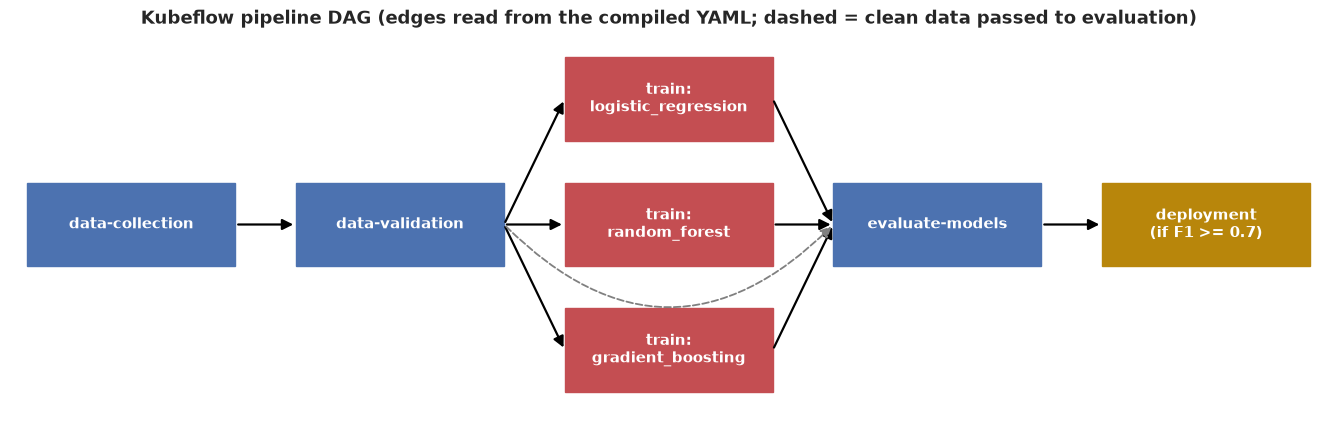

In [28]:
model_types = {name: task["inputs"]["parameters"]["model_type"]["runtimeValue"]["constant"]
               for name, task in tasks.items() if name.startswith("train-model")}
positions = {"data-collection": (0, 2), "data-validation": (3.1, 2), "evaluate-models": (9.3, 2), "deployment": (12.4, 2)}
positions.update({name: (6.2, y) for name, y in zip(sorted(model_types), [3.5, 2, 0.5])})
labels = {name: name for name in positions}
labels.update({name: f"train:\n{model_types[name]}" for name in model_types})
labels["deployment"] = "deployment\n(if F1 >= 0.7)"
edges = []
for name, task in tasks.items():
    target = "deployment" if name.startswith("condition") else name
    edges += [(dep, target) for dep in task.get("dependentTasks", []) if dep in positions]

fig, ax = plt.subplots(figsize=(17, 5))
for name, (x, y) in positions.items():
    color = "#C44E52" if name.startswith("train") else "#B8860B" if name == "deployment" else "#4C72B0"
    ax.add_patch(plt.Rectangle((x, y), 2.4, 1, color=color))
    ax.text(x + 1.2, y + 0.5, labels[name], ha="center", va="center", color="white", fontsize=10.5, fontweight="bold")
for src, dst in set(edges):
    (x1, y1), (x2, y2) = positions[src], positions[dst]
    skip = x2 - x1 > 3.2
    ax.add_patch(FancyArrowPatch((x1 + 2.4, y1 + 0.5), (x2, y2 + 0.5), arrowstyle="-|>", mutation_scale=16,
                                 lw=1.3 if skip else 1.6, color="gray" if skip else "black",
                                 linestyle="--" if skip else "-", connectionstyle="arc3,rad=0.5" if skip else "arc3"))
ax.set_xlim(-0.2, 15)
ax.set_ylim(0.2, 4.8)
ax.axis("off")
ax.set_title("Kubeflow pipeline DAG (edges read from the compiled YAML; dashed = clean data passed to evaluation)",
             fontsize=13, fontweight="bold")
plt.savefig("reports/kubeflow_pipeline.png", dpi=130, bbox_inches="tight")
plt.show()

The DAG is drawn from the dependencies in the compiled YAML. Validation fans out to three parallel training branches, which join again at evaluation, and deployment sits behind the F1 quality gate.

### 5.4 Pipeline Execution with the KFP Local Runner

In [29]:
from IPython.utils.capture import capture_output

kfp_root = Path("kfp_local_outputs").resolve()
local.init(runner=local.SubprocessRunner(use_venv=False), pipeline_root=str(kfp_root))
start = time.perf_counter()
with capture_output() as captured:
    build_pipeline(gate_in_dag=False)()
kfp_log = re.sub(r"\x1b\[[0-9;]*m", "", captured.stdout + captured.stderr)
Path("reports/kfp_local_run.log").write_text(kfp_log)
print("\n".join(line.strip() for line in kfp_log.splitlines() if "finished with status" in line))
print(f"\nTotal time: {time.perf_counter() - start:.0f} s | full log: reports/kfp_local_run.log")

15:16:48.440 - INFO - Task 'data-collection' finished with status SUCCESS
15:16:50.393 - INFO - Task 'data-validation' finished with status SUCCESS
15:16:55.070 - INFO - Task 'train-model-2' finished with status SUCCESS
15:16:57.788 - INFO - Task 'train-model' finished with status SUCCESS
15:17:00.995 - INFO - Task 'train-model-3' finished with status SUCCESS
15:17:04.341 - INFO - Task 'evaluate-models' finished with status SUCCESS
15:17:06.416 - INFO - Task 'deployment' finished with status SUCCESS
15:17:06.422 - INFO - Pipeline 'ai4i-predictive-maintenance' finished with status SUCCESS


Total time: 26 s | full log: reports/kfp_local_run.log

The pipeline really ran: KFP's local runner executed each component as a separate process, in DAG order, passing artifacts through files under `kfp_local_outputs/`. Every task finished with status SUCCESS. The full step-by-step log, including each component's own printout, is saved to `reports/kfp_local_run.log`.

Run folder:

ai4i-predictive-maintenance-2026-10-03-15-16-40-951551

Best model from the pipeline:

{'best_model_type': 'gradient_boosting', 'best_f1': 0.9047619047619048}

Deployment step returned:

READY_FOR_SERVING

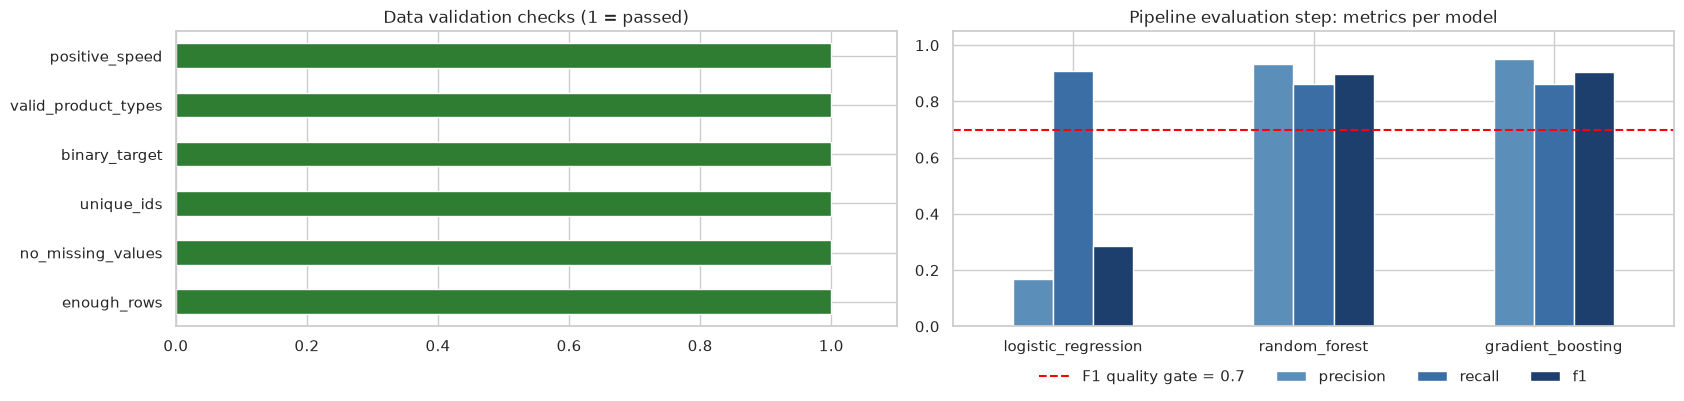

In [30]:
run_dir = max(kfp_root.glob("ai4i-predictive-maintenance-*"), key=lambda p: p.stat().st_mtime)


def task_output(task):
    return json.loads((run_dir / task / "executor_output.json").read_text())


validation_report = task_output("data-validation")["artifacts"]["report"]["artifacts"][0]["metadata"]
evaluation_output = task_output("evaluate-models")
evaluation_metrics = evaluation_output["artifacts"]["metrics"]["artifacts"][0]["metadata"]
pipeline_best = evaluation_output["parameterValues"]
deployment_status = task_output("deployment")["parameterValues"]["Output"]
print("Run folder:", run_dir.name)
print("Best model from the pipeline:", pipeline_best)
print("Deployment step returned:", deployment_status)

fig, axes = plt.subplots(1, 2, figsize=(17, 4.2))
checks_series = pd.Series(validation_report)
checks_series.plot.barh(ax=axes[0], color=["#2E7D32" if v == 1 else "#C62828" for v in checks_series])
axes[0].set_title("Data validation checks (1 = passed)")
axes[0].set_xlim(0, 1.1)
eval_df = pd.DataFrame({m: {k: evaluation_metrics[f"{m}_{k}"] for k in ["precision", "recall", "f1"]} for m in MODEL_TYPES}).T
eval_df.plot.bar(ax=axes[1], rot=0, color=["#5B8FB9", "#3B6EA5", "#1D3F6E"])
axes[1].axhline(0.7, color="red", linestyle="--", label="F1 quality gate = 0.7")
axes[1].set_title("Pipeline evaluation step: metrics per model")
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False)
plt.tight_layout()
plt.savefig("reports/kubeflow_results.png", dpi=120, bbox_inches="tight")
plt.show()

These results are read from the artifacts the pipeline wrote:
- **Validation:** all six checks passed.
- **Evaluation:** Random Forest and Gradient Boosting are both well above the 0.7 quality gate, and Logistic Regression is far below it.
- **Selection:** the pipeline picked Gradient Boosting (F1 0.905 on its evaluation split), while section 4.8 picked Random Forest. The selection rules differ: the pipeline uses held-out F1, the notebook uses cross-validated F1. The two models are close.
- **Deployment:** the step returned `READY_FOR_SERVING` and packaged the model.

### 5.5 How Automation Improves Reproducibility and Scalability

**Reproducibility**
- Every step runs from versioned code in a pinned container image, so the same inputs always produce the same outputs.
- All settings (data URL, seed, F1 threshold) are pipeline parameters recorded with each run. There are no manual edits between steps.
- Each step's artifacts and metrics are stored (see `kfp_local_outputs/`), giving full lineage from the packaged model back to its data.
- Steps share nothing except their declared artifacts, so no hidden notebook state can influence the result.
- Validation and the quality gate are code, so bad data or a weak model is rejected the same way every time.

**Scalability**
- **Parallelism:** the three training steps are independent, so a Kubeflow cluster runs them at the same time on separate pods.
- **Per-step resources:** training requests 2 CPUs and 4 GB here; a heavier model could request a GPU without changing any other step.
- **Efficiency:** caching skips unchanged steps, and retries absorb temporary failures such as a network error during download.
- **Same pipeline, bigger infrastructure:** the YAML that ran locally here also runs on Kubeflow or Vertex AI Pipelines, on a schedule or when monitoring detects drift.

## 6. Monitoring Stage: Drift Detection

In [31]:
def psi(reference, current, bins=10):
    edges = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    ref = np.histogram(np.clip(reference, edges[0], edges[-1]), edges)[0] / len(reference)
    cur = np.histogram(np.clip(current, edges[0], edges[-1]), edges)[0] / len(current)
    ref, cur = np.clip(ref, 1e-6, None), np.clip(cur, 1e-6, None)
    return float(np.sum((cur - ref) * np.log(cur / ref)))


drifted = X2_test.copy()
drifted["tool_wear_min"] = (drifted["tool_wear_min"] + 60).clip(upper=253)
drifted["torque_nm"] = drifted["torque_nm"] * 1.10
drifted["air_temp_k"] = drifted["air_temp_k"] + 1.5
drifted["temp_diff_k"] = drifted["process_temp_k"] - drifted["air_temp_k"]
drifted["power_w"] = drifted["torque_nm"] * drifted["rotational_speed_rpm"] * 2 * np.pi / 60
drifted["strain_min_nm"] = drifted["tool_wear_min"] * drifted["torque_nm"]

watch = ["air_temp_k", "torque_nm", "tool_wear_min", "rotational_speed_rpm"]
drift_report = pd.DataFrame({
    "ks_p_normal_batch": [ks_2samp(X2_train[c], X2_test[c]).pvalue for c in watch],
    "ks_p_drifted_batch": [ks_2samp(X2_train[c], drifted[c]).pvalue for c in watch],
    "psi_normal_batch": [psi(X2_train[c], X2_test[c]) for c in watch],
    "psi_drifted_batch": [psi(X2_train[c], drifted[c]) for c in watch],
}, index=watch).round(4)
drift_report["drift_detected"] = (drift_report["ks_p_drifted_batch"] < 0.05) | (drift_report["psi_drifted_batch"] > 0.2)
drift_report

,ks_p_normal_batch,ks_p_drifted_batch,psi_normal_batch,psi_drifted_batch,drift_detected
air_temp_k,0.9799,0.0000,0.0057,0.6645,True
torque_nm,0.5900,0.0000,0.0059,0.1634,True
tool_wear_min,0.2416,0.0000,0.0074,2.7779,True
rotational_speed_rpm,0.8519,0.8519,0.0014,0.0014,False


Monitoring compares new data with the training data in two ways:
- **Kolmogorov-Smirnov test:** a p-value below 0.05 means the distribution changed.
- **Population Stability Index (PSI):** below 0.1 is stable, 0.1–0.2 is a moderate shift, above 0.2 is a significant shift.

A normal new batch (the test set) shows no drift on either measure. A simulated batch with worn tools, 10% higher torque and warmer air is flagged on exactly those three features.

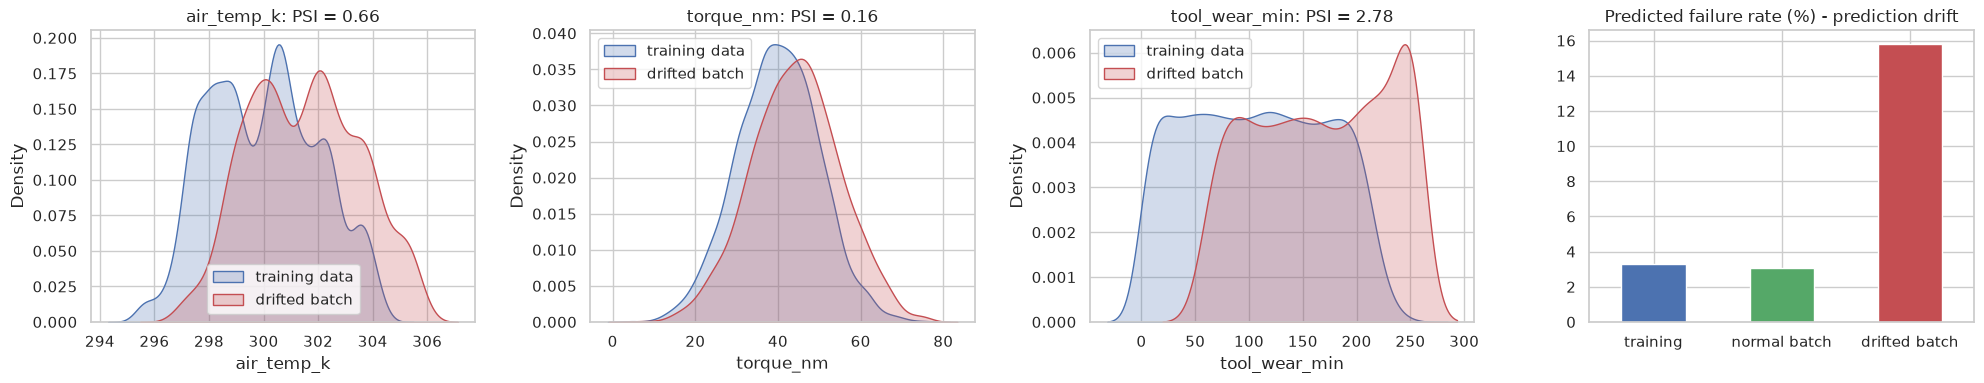

Decision:

TRIGGER RETRAINING PIPELINE

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes[:3], ["air_temp_k", "torque_nm", "tool_wear_min"]):
    sns.kdeplot(X2_train[col], ax=ax, label="training data", fill=True)
    sns.kdeplot(drifted[col], ax=ax, label="drifted batch", fill=True, color="#C44E52")
    ax.set_title(f"{col}: PSI = {drift_report.loc[col, 'psi_drifted_batch']:.2f}")
    ax.legend()
rates = pd.Series({"training": best_model.predict(X2_train).mean() * 100,
                   "normal batch": best_model.predict(X2_test).mean() * 100,
                   "drifted batch": best_model.predict(drifted[X2.columns]).mean() * 100})
rates.plot.bar(ax=axes[3], color=["#4C72B0", "#55A868", "#C44E52"], rot=0)
axes[3].set_title("Predicted failure rate (%) - prediction drift")
plt.tight_layout()
plt.savefig("reports/monitoring_drift.png", dpi=120, bbox_inches="tight")
plt.show()
print("Decision:", "TRIGGER RETRAINING PIPELINE" if drift_report["drift_detected"].any() else "No action")

The density plots show the drifted batch shifted away from the training distribution, with each feature's PSI in the title. The predicted failure rate also jumps for the drifted batch, which is a second warning sign (prediction drift). Because drift was detected, the monitoring stage would trigger the Kubeflow retraining pipeline from section 5.

## 7. Task 5A: Feast Feature Store

### 7.1 Three Features Selected for the Feast Demonstration

> **Scope note:** these three features were **selected to demonstrate Feast**. They are **not** the full feature set of the final model: the champion model uses all 11 v2 features. In production every model feature would be registered in Feast the same way.

| Feature | Unit | Why it was selected |
|---|---|---|
| `torque_nm` | Nm | Abnormal torque drives power failures and, combined with tool wear, overstrain failures |
| `rotational_speed_rpm` | rpm | Low speed with a small temperature difference causes heat-dissipation failures |
| `tool_wear_min` | minutes | Tools fail at 200–240 minutes of wear, and wear also drives overstrain |

The Feast entity is the machine (`machine_id`). The dataset has no time column, so each reading gets a synthetic `event_timestamp` one minute apart; Feast needs this to do point-in-time joins.

In [33]:
from feast import Entity, FeatureService, FeatureView, Field, FileSource, FeatureStore, ValueType
from feast.types import Float64, Int64

FEAST_FEATURES = ["torque_nm", "rotational_speed_rpm", "tool_wear_min"]
feature_repo = Path("feature_repo")
(feature_repo / "data").mkdir(parents=True, exist_ok=True)
start_time = datetime(2026, 1, 1, tzinfo=timezone.utc)

feature_df = df_v2[["machine_id"] + FEAST_FEATURES].copy()
feature_df["event_timestamp"] = start_time + pd.to_timedelta(feature_df["machine_id"] - 1, unit="m")
feature_df.to_parquet(feature_repo / "data/sensor_features.parquet", index=False)

(feature_repo / "feature_store.yaml").write_text('''project: ai4i_predictive_maintenance
registry: data/registry.db
provider: local
online_store:
  type: sqlite
  path: data/online_store.db
offline_store:
  type: file
entity_key_serialization_version: 3
''')
feature_df.head()

,machine_id,torque_nm,rotational_speed_rpm,tool_wear_min,event_timestamp
0,1,42.8,1551,0,2026-01-01 00:00:00+00:00
1,2,46.3,1408,3,2026-01-01 00:01:00+00:00
2,3,49.4,1498,5,2026-01-01 00:02:00+00:00
3,4,39.5,1433,7,2026-01-01 00:03:00+00:00
4,5,40.0,1408,9,2026-01-01 00:04:00+00:00


The three selected features, the machine ID and the timestamps are saved as a Parquet file, which serves as Feast's offline store. `feature_store.yaml` configures a local Feast project with a SQLite online store.

In [34]:
machine = Entity(name="machine", join_keys=["machine_id"], value_type=ValueType.INT64)
source = FileSource(path=str((feature_repo / "data/sensor_features.parquet").resolve()), timestamp_field="event_timestamp")
sensor_view = FeatureView(
    name="machine_sensor_features",
    entities=[machine],
    ttl=timedelta(days=30),
    schema=[Field(name="torque_nm", dtype=Float64), Field(name="rotational_speed_rpm", dtype=Int64),
            Field(name="tool_wear_min", dtype=Int64)],
    source=source,
)
demo_service = FeatureService(name="failure_demo_v1", features=[sensor_view])
store = FeatureStore(repo_path=str(feature_repo))
store.apply([machine, sensor_view, demo_service])
print("Registered entities:", [e.name for e in store.list_entities()])
print("Registered feature views:", [fv.name for fv in store.list_feature_views()])
print("Registered feature services:", [fs.name for fs in store.list_feature_services()])

Registered entities:

['machine']

Registered feature views:

['machine_sensor_features']

Registered feature services:

['failure_demo_v1']

The entity, the data source and the feature view are defined once and registered with `store.apply`, which is the same thing the `feast apply` command does. The `failure_demo_v1` FeatureService pins exactly which features the demo model uses, so training and serving request the same set by name.

In [35]:
entity_df = df_v2[["machine_id", "machine_failure"]].assign(event_timestamp=feature_df["event_timestamp"])
training_df = store.get_historical_features(entity_df=entity_df,
                                            features=store.get_feature_service("failure_demo_v1")).to_df()
print("Training data from the Feast offline store:", training_df.shape)

check_df = entity_df.head(4).drop(columns="machine_failure")
check_df["event_timestamp"] = check_df["event_timestamp"] + pd.to_timedelta([-30, -30, 30, 30], unit="s")
print("Point-in-time check: machines 1-2 requested BEFORE their reading existed, machines 3-4 after:")
store.get_historical_features(entity_df=check_df, features=store.get_feature_service("failure_demo_v1")).to_df()

Training data from the Feast offline store:

(9973, 6)

Point-in-time check: machines 1-2 requested BEFORE their reading existed, machines 3-4 after:

,machine_id,event_timestamp,torque_nm,rotational_speed_rpm,tool_wear_min
0,3,2026-01-01 00:02:30+00:00,49.4,1498,5
1,4,2026-01-01 00:03:30+00:00,39.5,1433,7


**Training path:** `get_historical_features` joins the three features to all 9,973 labelled rows through the FeatureService, giving a training-ready dataset.

**Point-in-time correctness:** machines 1 and 2 are requested 30 seconds before their readings existed, and Feast returns no rows for them. Only machines 3 and 4 come back, so data from the future can never leak into training.

In [36]:
train_ids = df_v2.loc[X2_train.index, "machine_id"]
train_part = training_df[training_df["machine_id"].isin(train_ids)]
test_part = training_df[~training_df["machine_id"].isin(train_ids)]
demo_model = RandomForestClassifier(n_estimators=100, class_weight="balanced_subsample", random_state=SEED)
demo_model.fit(train_part[FEAST_FEATURES], train_part["machine_failure"])
print(f"Demo model on the 3 Feast features only (not the final model): test F1 = "
      f"{f1_score(test_part['machine_failure'], demo_model.predict(test_part[FEAST_FEATURES])):.4f}")

store.materialize(start_date=start_time - timedelta(days=1), end_date=start_time + timedelta(days=8))
test_rows = df_v2.loc[X2_test.index]
sample_ids = (test_rows[test_rows["machine_failure"] == 1]["machine_id"].head(3).tolist()
              + test_rows[test_rows["machine_failure"] == 0]["machine_id"].head(2).tolist())
online = store.get_online_features(features=store.get_feature_service("failure_demo_v1"),
                                   entity_rows=[{"machine_id": i} for i in sample_ids]).to_df()
online = online[["machine_id"] + FEAST_FEATURES]
offline = training_df.set_index("machine_id").loc[sample_ids, FEAST_FEATURES].reset_index()
online["demo_prediction"] = demo_model.predict(online[FEAST_FEATURES])
online["actual"] = df_v2.set_index("machine_id").loc[sample_ids, "machine_failure"].values
print("Online (inference) values identical to offline (training) values:",
      np.allclose(online[FEAST_FEATURES].values, offline[FEAST_FEATURES].values))
online

Demo model on the 3 Feast features only (not the final model): test F1 = 0.4946

Materializing 

1

 feature views from 

2025-12-31 00:00:00+00:00

...

machine_sensor_features

:

Online (inference) values identical to offline (training) values:

True

,machine_id,torque_nm,rotational_speed_rpm,tool_wear_min,demo_prediction,actual
0,3237,62.4,1342,113,0,1
1,6800,12.2,2636,100,1,1
2,4442,50.6,1329,148,0,1
3,9244,49.0,1454,166,0,0
4,1313,42.6,1473,164,0,0


**Inference path:** `materialize` loads the latest values into the SQLite online store, and `get_online_features` serves them by machine ID through the same FeatureService. The online values are identical to the offline training values, so there is no training-serving skew.

The demo model uses only the three Feast features. It reaches F1 0.49, far below the champion's 0.90, which confirms that these three features are a demonstration selection, not the final model. It catches the power failure (machine 6800: 12.2 Nm at 2,636 rpm) but misses the two heat-dissipation failures, which need the temperature features it does not have.

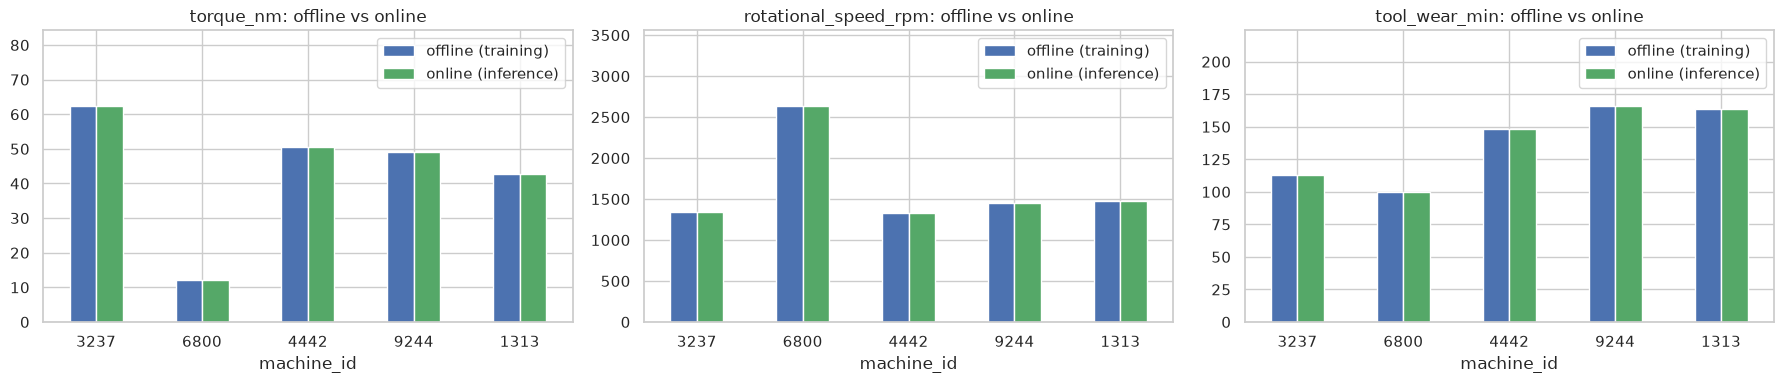

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, feature in zip(axes, FEAST_FEATURES):
    pd.DataFrame({"offline (training)": offline[feature].values, "online (inference)": online[feature].values},
                 index=sample_ids).plot.bar(ax=ax, rot=0, color=["#4C72B0", "#55A868"])
    ax.set_ylim(0, offline[feature].max() * 1.35)
    ax.set_title(f"{feature}: offline vs online")
    ax.set_xlabel("machine_id")
plt.tight_layout()
plt.savefig("reports/feast_consistency.png", dpi=120, bbox_inches="tight")
plt.show()

For each selected feature, the offline (training) and online (inference) bars are equal for every machine, which shows visually that Feast serves consistent features.

### 7.2 How Feast Manages and Serves Features Consistently

1. **One definition:** the three features are defined once, in the `machine_sensor_features` feature view. Training code and the serving service request them by the same names, so their logic cannot drift apart.
2. **Versioned feature sets:** the `failure_demo_v1` FeatureService pins exactly which features a model uses. A future model with more features would get its own service, so older models keep receiving what they expect.
3. **Offline store for training:** `get_historical_features` performs point-in-time joins on `event_timestamp`, so each label only sees sensor values known at that moment.
4. **Online store for inference:** `materialize` copies the latest values into a low-latency store (SQLite here; Redis, DynamoDB or Bigtable in production), and `get_online_features` serves them by `machine_id`.
5. **Consistency:** both stores are filled from the same source and definition. The check above proves that online values equal offline values.
6. **Governance and reuse:** the registry records the schema, TTL and services, so other models can reuse the same features.

## 8. Task 5B: Cloud Platform Comparison

| Criterion | AWS SageMaker | Google Cloud Vertex AI | IBM Watson Studio (watsonx.ai) |
|---|---|---|---|
| **Services offered** | Studio IDE, Training and Processing jobs, SageMaker Pipelines, Feature Store, Model Registry, Clarify, Model Monitor, Ground Truth, JumpStart | Workbench, Custom Training, Vertex AI Pipelines (runs Kubeflow and TFX pipelines), Feature Store, Model Registry, Model Monitoring, Explainable AI, Model Garden, BigQuery integration | Notebooks, SPSS Modeler flows, Data Refinery, AutoAI, Watson Machine Learning, watsonx.governance and OpenScale for monitoring |
| **Experiment tracking** | SageMaker Experiments, plus managed MLflow tracking servers | Vertex AI Experiments with Vertex AI TensorBoard; works with MLflow | AutoAI experiment leaderboards and run history; MLflow can be used from notebooks |
| **AutoML support** | SageMaker Autopilot, now part of SageMaker Canvas (no-code) | Vertex AI AutoML for tabular, image, text and video data | AutoAI: automatic data preparation, model selection, feature engineering and tuning |
| **Deployment options** | Real-time endpoints, serverless inference, asynchronous inference, batch transform, multi-model endpoints | Online prediction endpoints, batch prediction, private endpoints; export to GKE or Cloud Run | Online (REST) and batch deployments via deployment spaces; IBM Cloud, on-premise or hybrid via Cloud Pak for Data |
| **Cost considerations** | Pay per second for instances; 2-month free tier on selected instance types; Spot training can cut cost by up to 90% | Pay per node-hour for training and prediction; Pipelines charged per run plus compute; $300 free credit for new Google Cloud accounts | Billed in Capacity Unit Hours (CUH); free Lite plan with a monthly CUH allowance; enterprise licensing for on-premise use |

**Recommendation for this project: Google Cloud Vertex AI.**
- Vertex AI Pipelines runs Kubeflow pipelines natively, so `pipelines/ai4i_pipeline.yaml` from Task 4 could be submitted there unchanged.
- MLflow runs would map to Vertex AI Experiments, the registered champion to the Vertex AI Model Registry, and the Feast feature view to Vertex AI Feature Store.

**When the others fit better:**
- **SageMaker:** teams already on AWS that need flexible inference options such as serverless and asynchronous endpoints.
- **Watson Studio:** regulated enterprises that need on-premise or hybrid deployment with built-in governance.

## 9. Results Summary

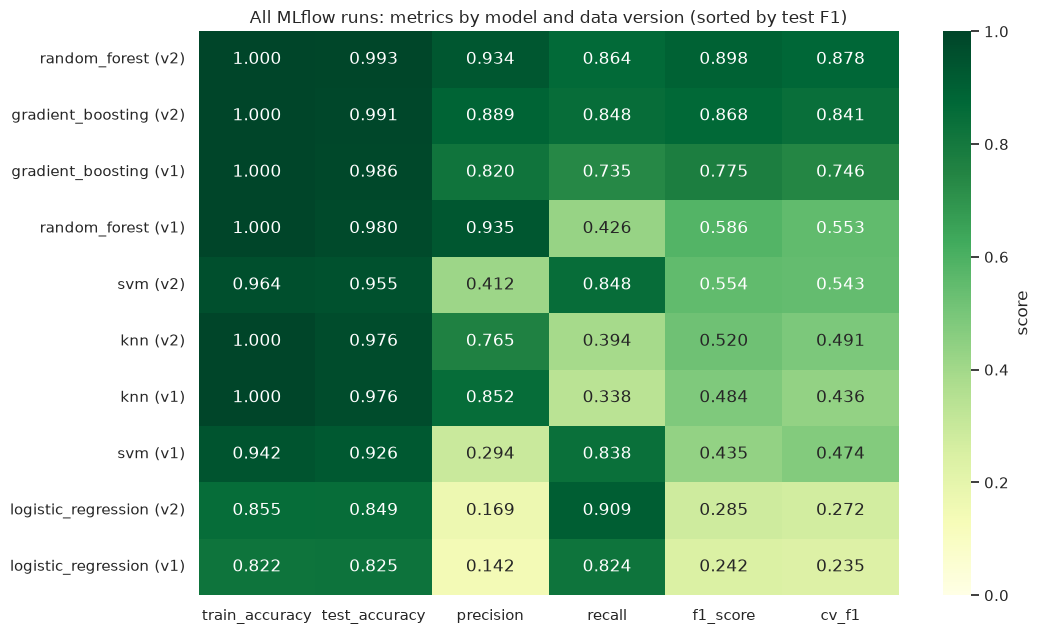

,Stage,Item,Result
0,Data,Rows v1 -> v2,"10,000 -> 9,973"
1,DVC,Dataset versions,"data-v1.0, data-v2.0"
2,MLflow,Runs logged,10 (5 models x 2 data versions)
3,MLflow,Registry champion,"random_forest on v2, test F1 0.8976"
4,Kubeflow,Pipeline,"compiled + executed locally, best gradient_boo..."
5,Monitoring,Drift check,"air_temp_k, torque_nm, tool_wear_min drifted -..."
6,Feast,Features served,"torque_nm, rotational_speed_rpm, tool_wear_min..."


In [38]:
summary = load_runs()
summary.index = summary["model"] + " (" + summary["data_version"] + ")"
plt.figure(figsize=(11, 6.5))
sns.heatmap(summary[METRICS], annot=True, fmt=".3f", cmap="YlGn", vmin=0, vmax=1, cbar_kws={"label": "score"})
plt.title("All MLflow runs: metrics by model and data version (sorted by test F1)")
plt.tight_layout()
plt.savefig("reports/results_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

pd.DataFrame([
    ["Data", "Rows v1 -> v2", f"{len(df_raw):,} -> {len(df_v2):,}"],
    ["DVC", "Dataset versions", "data-v1.0, data-v2.0"],
    ["MLflow", "Runs logged", f"{len(summary)} (5 models x 2 data versions)"],
    ["MLflow", "Registry champion", f"{best['model']} on v2, test F1 {best['f1_score']:.4f}"],
    ["Kubeflow", "Pipeline", f"compiled + executed locally, best {pipeline_best['best_model_type']} "
                             f"(F1 {pipeline_best['best_f1']:.4f}), deployment {deployment_status}"],
    ["Monitoring", "Drift check", ", ".join(drift_report.index[drift_report["drift_detected"]]) + " drifted -> retrain"],
    ["Feast", "Features served", ", ".join(FEAST_FEATURES) + " (demo selection)"],
], columns=["Stage", "Item", "Result"])

The heatmap collects all 10 MLflow runs in one view. Random Forest on v2 has the best test F1 (0.898) and is the registered champion, and every model scores a higher F1 on v2 than on v1. The table below it summarises the result of every MLOps stage in this notebook.

## 10. Five-Minute Demo Plan

| Time | What to show |
|---|---|
| 0:00 - 0:30 | Problem and dataset: 10,000 sensor records, 3.4% failures, why accuracy is misleading |
| 0:30 - 1:00 | Task 1: lifecycle diagram with the validation step and the monitoring feedback loop |
| 1:00 - 2:00 | Task 2: MLflow UI (`mlflow ui --backend-store-uri sqlite:///mlflow.db`): compare runs, open a confusion matrix, show the `champion` in the Model Registry |
| 2:00 - 2:50 | Task 3: `git log` with the data tags, `dvc diff`, switching versions, the v1 vs v2 F1 chart |
| 2:50 - 3:50 | Task 4: pipeline code, compiled YAML, DAG with parallel training, the local run log and evaluation chart |
| 3:50 - 4:30 | Monitoring drift charts (KS and PSI), and the Feast offline vs online consistency chart |
| 4:30 - 5:00 | Task 5B cloud comparison and key takeaways |

## 11. Conclusion

- **Task 1:**
  - The lifecycle was drawn and every required stage was identified for AI4I 2020, plus an explicit data-validation step.
- **Task 2:**
  - Five models were tracked in MLflow with parameters, train and test accuracy, precision, recall, F1, the training dataset and the saved model, and were compared through MLflow.
  - The champion was registered in the Model Registry.
- **Task 3:**
  - DVC versioned the original and preprocessed datasets as `data-v1.0` and `data-v2.0`.
  - Preprocessing raised F1 for every model.
- **Task 4:**
  - A Kubeflow pipeline with parallel training branches and an F1 quality gate was compiled with the real KFP compiler and executed with the KFP local runner.
- **Task 5A:**
  - Three features selected for the demonstration were served consistently by Feast offline and online through a FeatureService, with point-in-time correctness.
- **Task 5B:**
  - SageMaker, Vertex AI and Watson Studio were compared on five criteria, and Vertex AI is recommended for this workload.